# Notebook: Análisis de Tendencias en la Educación Superior Chilena (2007-2024)

## Configuracion Inicial

In [1]:
# =============================================================================
# Installs
# =============================================================================

!pip install unidecode

# =============================================================================
# Imports
# =============================================================================

import numpy as np
import pandas as pd
import unidecode
import re
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, ScalarFormatter
import seaborn as sns
from pathlib import Path

# =============================================================================
# Configuration
# =============================================================================

BASE_PATH = Path.cwd()

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 5.7 MB/s eta 0:00:00


## Análisis Exploratorio de Datos (EDA)

En el **EDA**, se trabajará con el 5% de los registros, elegidos de manera aleatorea ya que el dataset original es de ~12 gb de datos y con ~20 millones de registros, lo que podria dificultar el análisis en algunos dispositivos.

**Recursos:**
- [Consulta SQL](https://github.com/FeliProjects/analisis-educacion-superior-chile/blob/main/sql/01_muestreo_eda.sql)
- [Dataset](https://drive.proton.me/urls/TC6XN1TSYM#OYuibm2uah7v)

In [2]:
# Carga del dataset
file_path_muestra = BASE_PATH / "muestra_estudiantes_dataset.csv"

df_muestra = pd.read_csv(file_path_muestra)
df_muestra.drop(columns=['Unnamed: 0'], inplace=True)

df_muestra.head()

,cat_periodo,id,codigo_unico,mrun,gen_alu,fec_nac_alu,rango_edad,anio_ing_carr_ori,sem_ing_carr_ori,anio_ing_carr_act,sem_ing_carr_act,tipo_inst_1,tipo_inst_2,tipo_inst_3,cod_inst,nomb_inst,cod_sede,nomb_sede,cod_carrera,nomb_carrera,modalidad,jornada,version,tipo_plan_carr,dur_estudio_carr,dur_proceso_tit,dur_total_carr,region_sede,provincia_sede,comuna_sede,nivel_global,nivel_carrera_1,nivel_carrera_2,requisito_ingreso,vigencia_carrera,valor_matricula,valor_arancel,codigo_demre,area_conocimiento,cine_f_97_area,cine_f_97_subarea,area_carrera_generica,cine_f_13_area,cine_f_13_subarea,acreditada_carr,acreditada_inst,acre_inst_desde_hasta,acre_inst_anio,costo_proceso_titulacion,costo_obtencion_titulo_diploma,costo_tit_explicacion_observacion,forma_de_ingreso
0,2010,609394,I111S5C50J2V1,11029936.0,1,198808,20 a 24 años,2008.0,1.0,NaN,NaN,Institutos Profesionales,Institutos Profesionales,Institutos Profesionales,111,IP DUOC UC,5.0,SEDE ANTONIO VARAS,50.0,INGENIERIA EN CONECTIVIDAD Y REDES,NaN,Vespertina,1.0,Plan Regular,8.0,0.0,8.0,Metropolitana,SANTIAGO,PROVIDENCIA,Pregrado,Profesional Sin Licenciatura,Carreras Profesionales,NaN,NaN,NaN,166000.0,1680000.0,NaN,Tecnología,Ciencias,Informática,Ingeniería en Conectividad y Redes,Tecnología de la Información y la Comunicación...,Tecnología de la Información y la Comunicación...,ACREDITADA,ACREDITADA,NaN,NaN,NaN,NaN,NaN
1,2022,1107501,I111S12C110J1V1,16733351.0,2,198906,30 a 34 años,2020.0,1.0,2022.0,1.0,Institutos Profesionales,Institutos Profesionales,Institutos Profesionales,111,IP DUOC UC,12.0,SEDE PUENTE ALTO,110.0,TECNICO VETERINARIO Y PECUARIO,Presencial,Diurna,1.0,Plan Regular,5.0,1.0,5.0,Metropolitana,CORDILLERA,PUENTE ALTO,Pregrado,Técnico de Nivel Superior,Carreras Técnicas,Educación Media,VIGENTE CON ALUMNOS NUEVOS,Monto en Pesos,204000.0,2360000.0,0.0,Agropecuaria,Agricultura,Veterinaria,Técnico Veterinario,"Agricultura, Silvicultura, Pesca y Veterinaria",Veterinaria,ACREDITADA,ACREDITADA,26/08/2017 - 26/08/2024,7.0,0,0,3.0
2,2023,969750,I116S25C196J2V1,5913557.0,2,200303,20 a 24 años,2023.0,1.0,2023.0,1.0,Institutos Profesionales,Institutos Profesionales,Institutos Profesionales,116,IP SANTO TOMAS,25.0,SEDE RANCAGUA,196.0,PSICOPEDAGOGIA,Presencial,Vespertina,1.0,Plan Regular,8.0,0.0,8.0,Lib. Gral. B. O'Higgins,CACHAPOAL,RANCAGUA,Pregrado,Profesional Sin Licenciatura,Carreras Profesionales,Educación Media,VIGENTE CON ALUMNOS NUEVOS,Monto en Pesos,110000.0,2124000.0,NaN,Educación,Educación,Formación de Personal Docente y Ciencias de la...,Psicopedagogía,Educación,Educación,NO ACREDITADA,ACREDITADA,20/01/2021 - 20/01/2026,5.0,0,0,1.0
3,2012,74495,I430S29C39J1V1,13968062.0,2,198711,20 a 24 años,2012.0,1.0,NaN,NaN,Centros de Formación Técnica,Centros de Formación Técnica,Centros de Formación Técnica,430,CFT INACAP,29.0,SEDE LOS ANGELES,39.0,TECNICO EN ENFERMERIA,Presencial,Diurna,1.0,Plan Regular,4.0,0.0,4.0,Biobío,BIOBIO,LOS ANGELES,Pregrado,Técnico de Nivel Superior,Carreras Técnicas,NaN,NaN,NaN,200000.0,1379000.0,NaN,Salud,Salud y Servicios Sociales,Medicina,Técnico en Enfermería,Salud y Bienestar,Salud,NO ACREDITADA,ACREDITADA,ENE DE 2012 A ENE DE 2018,6.0,100000,NaN,NaN
4,2024,727336,I4S7C104J1V1,165237.0,2,200512,15 a 19 años,2024.0,1.0,2024.0,1.0,Universidades,Universidades Privadas,Universidades Privadas,4,UNIVERSIDAD CENTRAL DE CHILE,7.0,SEDE LA SERENA,104.0,NUTRICION Y DIETETICA,Presencial,Diurna,1.0,Plan Regular,10.0,0.0,10.0,Coquimbo,ELQUI,LA SERENA,Pregrado,Profesional Con Licenciatura,Carreras Profesionales,Educación Media,VIGENTE CON ALUMNOS NUEVOS,Monto en Pesos,297000.0,4080000.0,51253.0,Salud,Salud y Servicios Sociales,Medicina,Nutrición y Dietética,Salud y Bienestar,Salud,NO ACREDITADA,ACREDITADA,13/01/2022 - 13/01/2027,5.0,0,0,1.0


In [3]:
# Uso de memoria del 5% de los datos
print(f"Memoria usada: {df_muestra.memory_usage().sum() / 1e6:.2f} MB")

Memoria usada: 24.43 MB


Nota: Como el 5% del dataset ocupa 434 MB, se podría asumir, mediante una estimación lineal, que el dataset completo ocuparia ~8.7 GB. Es importante tener eso en cuenta si se desea ocupar el dataset completo en Python mediante Pandas.

In [4]:
# Ranking de nulos (%)
nulos = (df_muestra.isnull().sum() / len(df_muestra)) * 100
nulos.sort_values(ascending=False)

,0
valor_matricula,80.679825
forma_de_ingreso,56.383577
anio_ing_carr_act,39.309617
requisito_ingreso,38.788508
vigencia_carrera,38.512628
area_conocimiento,37.855282
sem_ing_carr_act,36.927164
costo_tit_explicacion_observacion,33.367960
costo_obtencion_titulo_diploma,32.906456
costo_proceso_titulacion,22.901517


Algunas variables presentan una gran proporcion de valores nulos. Esto puede ser crítico y representar dificultades para realizar ciertos análisis.

In [5]:
# Niveles de granularidad para el año 2007
columnas_interes = ['area_carrera_generica', 'cine_f_13_area', 'cine_f_97_area', 'area_conocimiento']

for col in columnas_interes:
    nulos = df_muestra[df_muestra['cat_periodo'] == 2007][col].isnull().sum()
    unicos = df_muestra[df_muestra['cat_periodo'] == 2007][col].nunique()
    print(f"Columna {col} (2007): {nulos} nulos, {unicos} categorías únicas.")

Columna area_carrera_generica (2007): 0 nulos, 22 categorías únicas.
Columna cine_f_13_area (2007): 0 nulos, 225 categorías únicas.
Columna cine_f_97_area (2007): 0 nulos, 10 categorías únicas.
Columna area_conocimiento (2007): 1687 nulos, 331 categorías únicas.


|Variable|Nulos|Cat. Únicas|
|:-|-:|-:|
|cine_f_97_area|0|10|
|area_carrera_generica|0|22|
|cine_f_13_area|0|293|
|area_conocimiento|30319|723|

Las categorías `cine_f_97_area` y `area_carrera_generica` son las que tienen menor nivel de granularidad por lo que servirían para analizar grupos de carreras.

La categoría `cine_f_13_area` tiene un alto nivel de granularidad con 293 categorías, por lo que serviría para analizar grupos de carreras mucho más especificos y relacionados entre ellos.

*Nota: Estos valores sólo son válidos para la muestra del 5%*

In [6]:
# Valores duplicados
print(f"Cantidad de filas duplicadas: {df_muestra.duplicated().sum()}")

Cantidad de filas duplicadas: 0


Que no existan valores duplicados en la muestra random de 5%, es un buen indicio preliminar. Podrian existir duplicados en el 95% de datos restante.

La variable `anio_ing_carr_ori` indica el año de ingreso a primer año de la carrera, sin embargo a veces incluye códigos de relleno como 1900, 9998 o 9999 cuando el dato histórico exacto no está disponible en los registros administrativos

In [7]:
# Conteo de valores de año de ingreso a primer año
mask_anio_ing = df_muestra["anio_ing_carr_ori"].isin([1900, 9999, 9995, 9998])
df_muestra[mask_anio_ing]["anio_ing_carr_ori"].value_counts()

,count
anio_ing_carr_ori,
9998.0,1139
9999.0,630
1900.0,431
9995.0,1


In [8]:
# Conteo de valores y verifiación granularidad de los tipos de institución
df_muestra[['tipo_inst_1', 'tipo_inst_2', 'tipo_inst_3']].value_counts()

tipo_inst_1                   tipo_inst_2                            tipo_inst_3                           
Universidades                 Universidades Privadas                 Universidades Privadas                    17172
Institutos Profesionales      Institutos Profesionales               Institutos Profesionales                  16642
Universidades                 Universidades CRUCH                    Universidades Estatales CRUCH              9686
                                                                     Universidades Privadas CRUCH               8529
Centros de Formación Técnica  Centros de Formación Técnica           Centros de Formación Técnica               6539
                                                                     Centros de Formación Técnica Estatales      133
Universidades                 Universidades (* Carrera en Convenio)  Universidades (* Carrera en Convenio)        20
Name: count, dtype: int64

De lo anterior se observa la granularidad declarada por MINEDUC corresponde con los datos. Se tiene lo siguiente:
- `tipo_inst_1`: Es la clasificacion mas general (universidades, institutos profesionales y centros de formacion tecnica)
- `tipo_inst_2`: Es una clasificación un poco mas detallada que la anterior ya que identifica los tipos de Universidades (Ues Privadas, Ues CRUCH y universidades con carreras con convenio, que son la minoria)
- `tipo_inst_3`: Es una clasificación aún más detallada que identifica a las Ues CRUCH Estatales y Privadas, y los Centro de Formación Técnica (CFT) Estatales.




In [9]:
df_muestra[['nivel_carrera_2', 'nivel_carrera_1']].value_counts()

nivel_carrera_2         nivel_carrera_1                         
Carreras Profesionales  Profesional Con Licenciatura                28197
Carreras Técnicas       Técnico de Nivel Superior                   15315
Carreras Profesionales  Profesional Sin Licenciatura                10592
Magister                Magister                                     2005
Postítulo               Diplomado (desde un semestre)                 740
Carreras Profesionales  Licenciatura No Conducente a Título           528
                        Bachillerato, Ciclo Inicial o Plan Común      524
Postítulo               Postítulo                                     334
Doctorado               Doctorado                                     255
Postítulo               Especialidad Médica U Odontológica            230
Name: count, dtype: int64

De las clasificaciones de carrera se observa que tambien corresponden con lo declarado por MINEDUC. Se tiene lo siguiente:
- `nivel_carrera_2`: Es la clasificación más general que `nivel_carrera_1`. Identifica Carreras Profesionales, Carreras Técnicas, Postítulo, Magíster y Doctorado.
- `nivel_carrera_1`: Esta clasificación separa mucho más las categorias, por ejemplo, profesional con licenciatura, sin licenciatura, especialidad medica u odontologica, etc.


In [10]:
# Resumen de clasificaciones CINE Unesco, area de conocimiento y area generica de carreras
print("cine_f_97_area: ", len(df_muestra['cine_f_97_area'].unique()))
#print(df_muestra['cine_f_97_area'].unique(), "\n")
print("cine_f_97_subarea: ", len(df_muestra['cine_f_97_subarea'].unique()))
#print(df_muestra['cine_f_97_subarea'].unique(), "\n")
print("cine_f_13_area: ", len(df_muestra['cine_f_13_area'].unique()))
#print(df_muestra['cine_f_13_area'].unique(), "\n")
print("cine_f_13_subarea: ", len(df_muestra['cine_f_13_subarea'].unique()))
#print(df_muestra['cine_f_13_subarea'].unique(), "\n")
print("area_carrera_generica: ", len(df_muestra['area_carrera_generica'].unique()))
#print(df_muestra['area_carrera_generica'].unique(), "\n")
print("area_conocimiento: ", len(df_muestra['area_conocimiento'].unique()))
#print(df_muestra['area_conocimiento'].unique())

cine_f_97_area:  11
cine_f_97_subarea:  9
cine_f_13_area:  302
cine_f_13_subarea:  11
area_carrera_generica:  23
area_conocimiento:  2984


De los valores anteriores se observa que las categorías declaradas por MINEDUC no corresponden con lo indicado por los datos.  lo siguiente:
- Al parecer las categorias `cine_f_13_area` y `cine_f_13_subarea` estan intercambiadas ya que el "area" esta indicando niveles más específicos el que "subarea".
- Según la documentación oficial, la variable `area_conocimiento` debería tener 11 categorías bien definidas, pero el dataset contiene valores numericos con demasiados valores únicos como para agrupar un area de conocimiento. Además, su cantidad de valores nulos ronda el 40%.
- El Instituto de Estadística de la UNESCO señala en su clasficación ([link](https://unesdoc.unesco.org/ark:/48223/pf0000229320)) que el nivel más detallado presenta alrededor de 80 campos, lo que no coincide con el numero de valores registrados en `cine_f_13_area`.

    <img src ="https://raw.githubusercontent.com/FeliProjects/analisis-educacion-superior-chile/refs/heads/main/assets/imagenes/07_campos_cine_f13_unesco.png" width=400 height=140>


### Resumen EDA (5%)

Del análisis previo realizado con la muestra del 5% de los datos se resume lo siguiente:

- ✔️ No se presentan datos duplicados
- ✔️ Las variables de interés `cine_f_13_area` y `cine_f_13_subarea` presentan el problema de que probablemente están cambiadas, sin embargo esto es facilmente solucionable. Ambas no poseen daton nulos.
- ✔️ Las variables de interes para el Business Objective 2 `tipo_inst_1`,`tipo_inst_2`, `tipo_inst_3`, `nivel_carrera_1` y `nivel_carrera_2` proporcionan suficiente nivel de detalle para el análisis y no presentan datos nulos.


- ❌ Existen variables con gran cantidad de valores nulos. 9 de ellos presentan un porcentaje mayor al 30% de datos faltantes. Esto podría limitar algun tipo de análisis futuro. Destaca `valor_matricula` con ~80% de datos nulos.
- ❌ La documentación oficial del Dataset provisto por MINEDUC contiene variables que no corresponden con lo señalado por los datos

## **Business Objective 1:** ¿Cómo ha cambiado la demanda por grandes áreas del conocimiento entre 2007 y 2024?

Como primer objetivo, se busca cuantificar el crecimiento porcentual anual por Área de Conocimiento.

Para responder esto, se utilizarán las variables `cat_periodo` y `area_carrera_generica`.

Ésta última variable se consideró debido a que es capaz de clasificar diferentes areas de estudio sin desmenuzar demasiado las categorias y que se pierdan relaciones. Esta variable maneja 22 categorías, lo que es casi el doble de las que manejan las variables `cine_f_97_subarea` y `cine_f_13_subarea`.

**Recursos:**
- [Consulta SQL](https://github.com/FeliProjects/analisis-educacion-superior-chile/blob/main/sql/02_bo1_evolucion_areas.sql)
- [Dataset](https://github.com/FeliProjects/analisis-educacion-superior-chile/blob/main/data/processed/bo_1_dataset.csv)

### I. Preparación y Transformación de Datos

In [11]:
# Carga de datos
bo1_file_path = BASE_PATH / "bo_1_dataset.csv"

df_evolucion = pd.read_csv(bo1_file_path)
df_evolucion.drop(columns=['Unnamed: 0'], inplace=True)

df_evolucion.head()

,cat_periodo,area_carrera_generica,total_alumnos
0,2007,"Agricultura, Silvicultura y Pesca",18011
1,2007,Arquitectura y Construcción,37844
2,2007,Artes,35068
3,2007,Ciencias de la Vida,6115
4,2007,Ciencias Físicas,9298


In [12]:
# Exploración del DataFrame
print("INFO")
print(df_evolucion.info())

INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396 entries, 0 to 395
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   cat_periodo            396 non-null    int64 
 1   area_carrera_generica  396 non-null    object
 2   total_alumnos          396 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 9.4+ KB
None


In [13]:
# Pivotear la tabla para tener los años como índice y las áreas como columnas
df_pivot = df_evolucion.pivot_table(index='cat_periodo',
                              columns='area_carrera_generica',
                              values='total_alumnos',
                              aggfunc='sum')
# df_pivot

In [14]:
# Generar DF comparativo entre 2007 y 2024
df_comparativa = df_pivot.loc[[2007, 2024]].T
df_comparativa

cat_periodo,2007,2024
area_carrera_generica,,
"Agricultura, Silvicultura y Pesca",18011,18002
Arquitectura y Construcción,37844,57878
Artes,35068,46336
Ciencias Físicas,9298,14696
Ciencias Sociales y del Comportamiento,36438,71738
Ciencias de la Vida,6115,9875
Derecho,63470,58519
Enseñanza Comercial y Administración,110132,250743
Formación de Personal Docente y Ciencias de la Educación,116107,120302


### II. Análisis de Crecimiento Histórico (2007 - 2024)

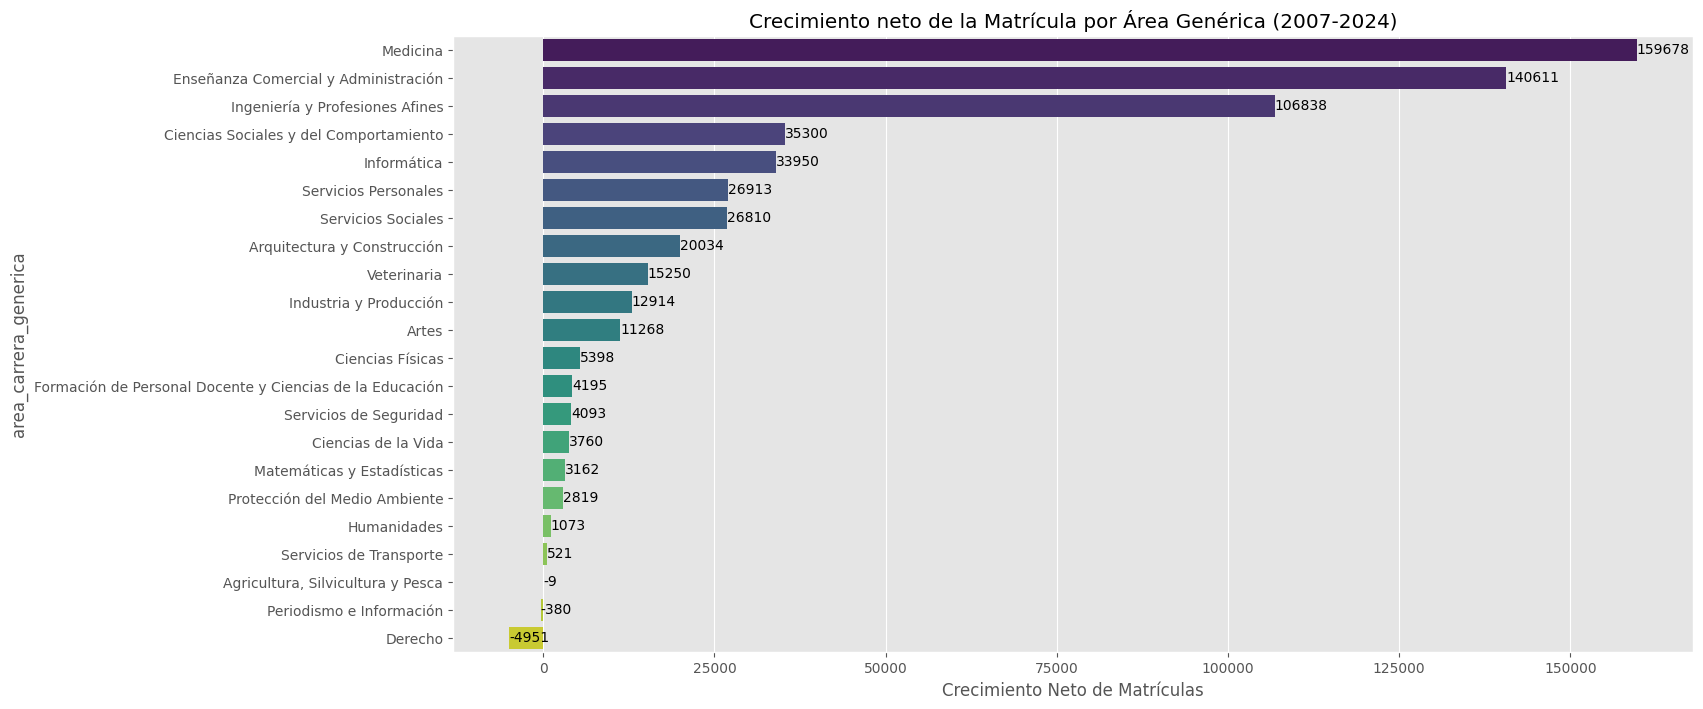

In [15]:
# Visualización del crecimiento neto de matriculas
df_comparativa['crecimiento_total_neto'] = (df_comparativa[2024] - df_comparativa[2007])

# Ordenar por las que más crecieron
df_comparativa = df_comparativa.sort_values(by='crecimiento_total_neto', ascending=False)

# Gráfico de barras
plt.figure(figsize=(16, 8))
sns.barplot(x=df_comparativa['crecimiento_total_neto'], y=df_comparativa.index,
            hue=df_comparativa.index, palette='viridis')
# el valor sobre las barras
for i, v in enumerate(df_comparativa['crecimiento_total_neto']):
    plt.text(v + 0.1, i, f'{v}', va='center', fontsize=10)
plt.title('Crecimiento neto de la Matrícula por Área Genérica (2007-2024)')
plt.xlabel('Crecimiento Neto de Matrículas')
plt.show()

*OBS 1: En el gráfico anterior se observa que entre los años 2007 y 2024 existió un dominio de las preferencias de los estudiantes por las áreas de Medicina, Enseñanza Comercial y Administración, e Ingeniería y Profesiones Afines*

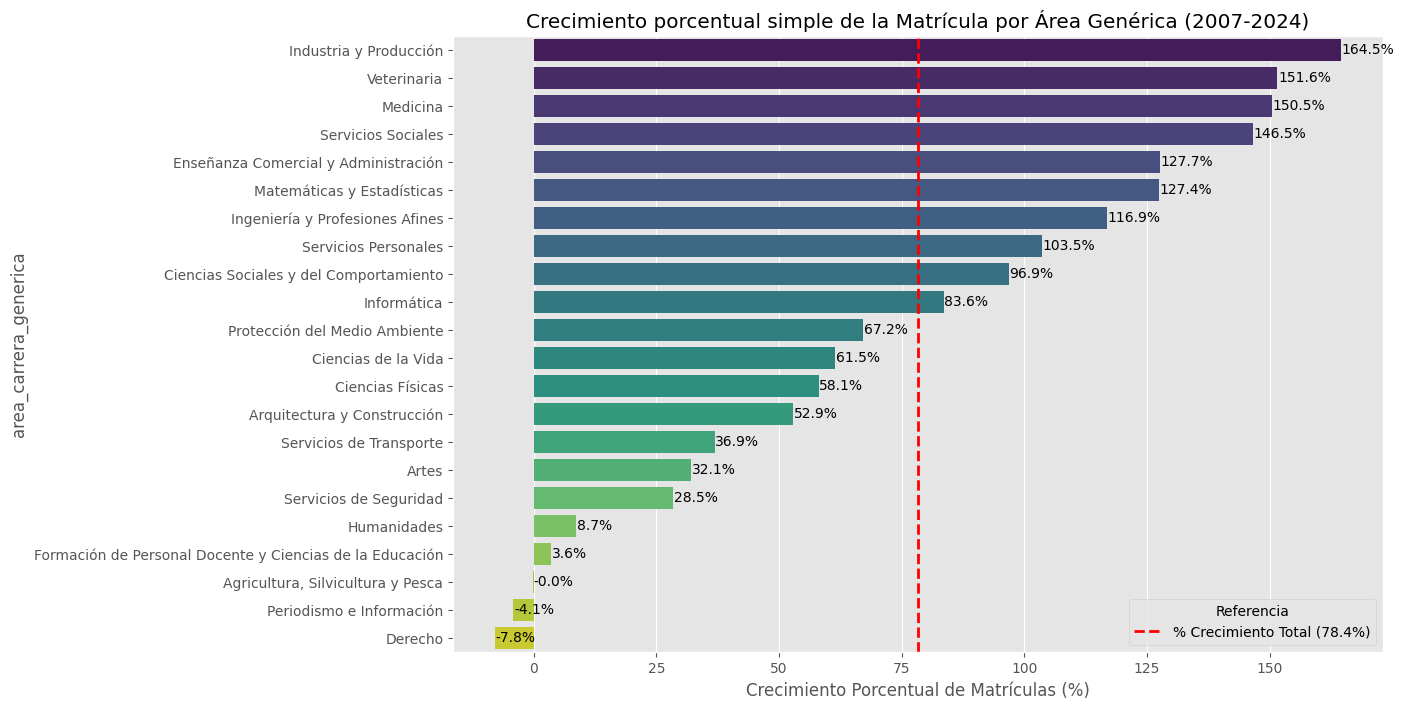

In [16]:
# Visualización del crecimiento porcentual de matriculas

# Filtrar solo el primer y último año
df_comparativa['crecimiento_total'] = ((df_comparativa[2024] - df_comparativa[2007]) / df_comparativa[2007]) * 100

total_2007 = df_comparativa[2007].sum()
total_2024 = df_comparativa[2024].sum()

crecimiento_anual_simple = ((total_2024 - total_2007) / total_2007) * 100

# Ordenar por las que más crecieron
df_comparativa = df_comparativa.sort_values(by='crecimiento_total', ascending=False)

# Gráfico de barras
plt.figure(figsize=(12, 8))
sns.barplot(x=df_comparativa['crecimiento_total'], y=df_comparativa.index,
            hue=df_comparativa.index, palette='viridis')
# Línea del promedio nacional
plt.axvline(x=crecimiento_anual_simple, color='red', linestyle='--', linewidth=2, label=f'% Crecimiento Total ({crecimiento_anual_simple:.1f}%)')
# el valor sobre las barras
for i, v in enumerate(df_comparativa['crecimiento_total']):
    plt.text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=10)
plt.title('Crecimiento porcentual simple de la Matrícula por Área Genérica (2007-2024)')
plt.xlabel('Crecimiento Porcentual de Matrículas (%)')
plt.legend(title="Referencia", loc='lower right')
plt.show()

*OBS 2: En este grafico se presenta el crecimiento porcentual "simple", el cual solo considera la cantidad inicial y final de los matriculados (2007 y 2024 respectivamente), esto es suceptible a malinterpretaciones debido a que no considera el tiempo en el que transcurre el cambio y las carreras con una menor base de compraración pueden verde beneficiadas de cualquier aumento neto con respecto al resto.*

In [17]:
# Sumamos todas las filas para obtener el total nacional por año
total_2007 = df_comparativa[2007].sum()
total_2024 = df_comparativa[2024].sum()

# Definimos el periodo (n)
years = 2024 - 2007

# Aplicamos la fórmula matemática del CAGR
# CAGR = [(Valor Final / Valor Inicial) ^ (1 / n)] - 1
cagr_total = ((total_2024 / total_2007) ** (1/years) - 1) * 100

print(f"La matrícula total creció un {cagr_total:.2f}% anual compuesto.")

La matrícula total creció un 3.46% anual compuesto.


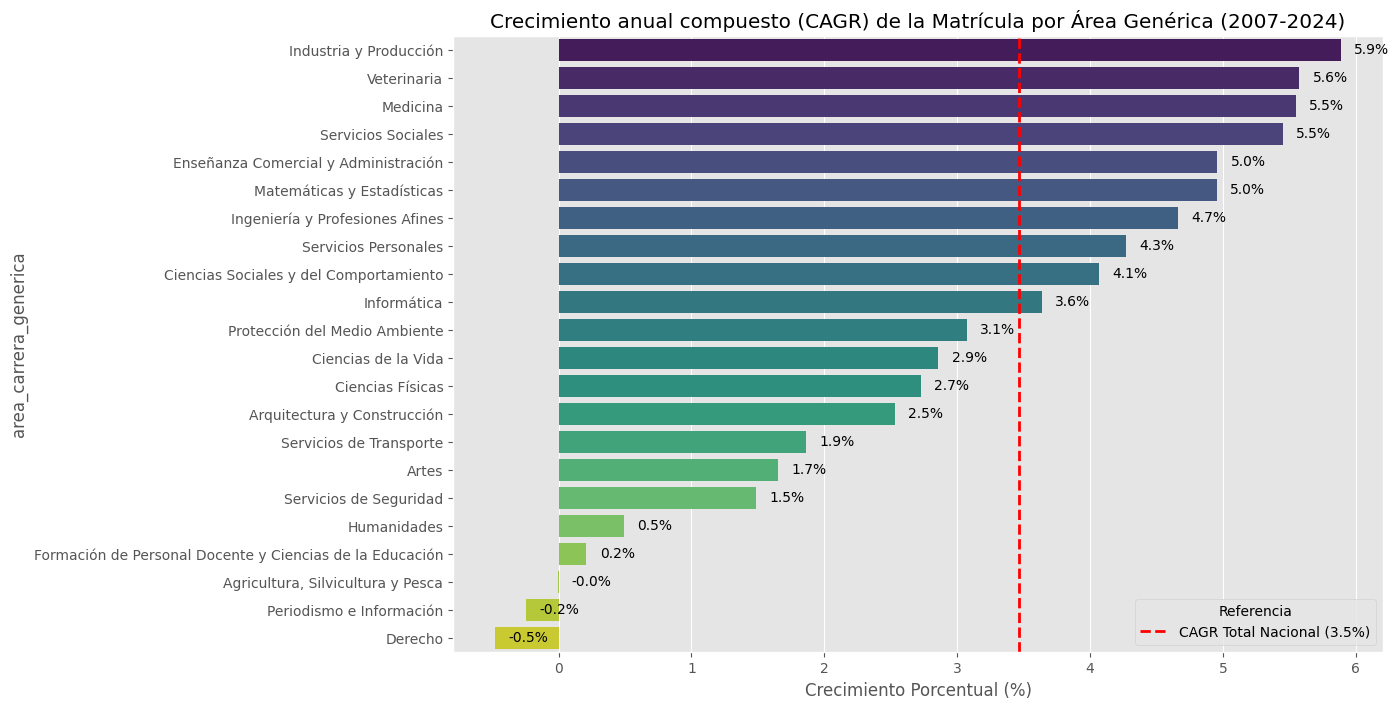

In [18]:
# Crecimiento anual compuesto (CAGR)

# Filtrar solo el primer y último año
years = 2024 - 2007
df_comparativa['CAGR'] = (
    (df_comparativa[2024] / df_comparativa[2007]) ** (1/years) - 1
) * 100

# Ordenar por las que más crecieron
df_comparativa = df_comparativa.sort_values(by='CAGR', ascending=False)

# Gráfico de barras
plt.figure(figsize=(12, 8))
sns.barplot(x=df_comparativa['CAGR'], y=df_comparativa.index,
            hue=df_comparativa.index, palette='viridis')
# Línea del promedio nacional
plt.axvline(x=cagr_total, color='red', linestyle='--', linewidth=2, label=f'CAGR Total Nacional ({cagr_total:.1f}%)')
# el valor sobre las barras
for i, v in enumerate(df_comparativa['CAGR']):
    plt.text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=10)
plt.title('Crecimiento anual compuesto (CAGR) de la Matrícula por Área Genérica (2007-2024)')
plt.xlabel('Crecimiento Porcentual (%)')
plt.legend(title="Referencia", loc='lower right')
plt.show()

*OBS 3: Debido al inconveniente en el gráfico anterior, se presenta el Crecimiento Anual Compuesto (CAGR). En este grafico es posible apreciar que casi la mitad de las áreas lograron crecer sobre la tasa de crecimiento de matriculas total (3.5%) y que las areas de Derecho y Periodismo e Información fueron las unicas que disminuyeron sus matriculas a lo largo de los años.*

### III. Análisis de Tendencias y Categorías

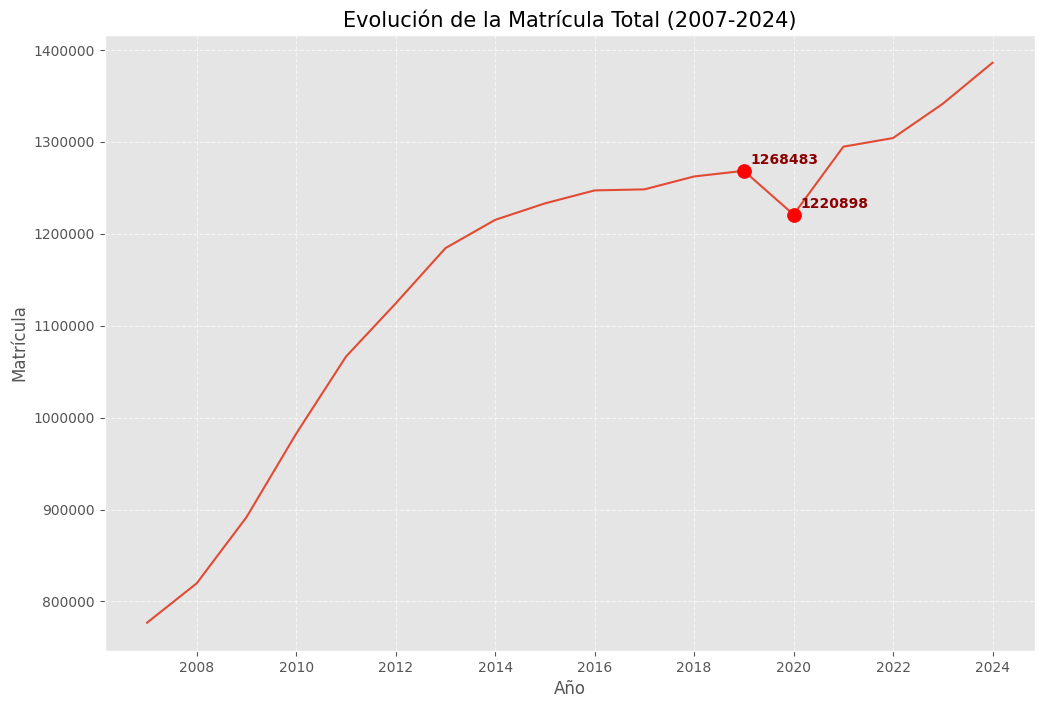

In [19]:
# visualizacion de la evolucion total de matriculas

# I. Preparación de datos
df_total = df_pivot.copy()
df_total["total"] = df_total.sum(axis=1)

# II. Configuración de la gráfica
plt.figure(figsize=(12, 8))
ax = sns.lineplot(data=df_total['total'], marker='o', markevery=[]) # marker opcional

# III. Años que quieres resaltar
años_interes = [2019, 2020]

for año in años_interes:
    # Verificamos que el año exista en el índice para evitar errores
    if año in df_total.index:
        valor = df_total.loc[año, 'total']

        # Dibujar el punto resaltado
        plt.scatter(año, valor, color='red', s=100, zorder=5)

        # Agregar el texto del valor
        # xytext indica el desplazamiento (5 puntos a la derecha, 5 arriba)
        plt.annotate(f'{int(valor)}',
                     xy=(año, valor),
                     xytext=(5, 5),
                     textcoords='offset points',
                     fontsize=10,
                     fontweight='bold',
                     color='darkred')

# IV. Estética final
# EJE X: Solo años enteros
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
# EJE Y: Quitar notación científica
formatter = ScalarFormatter()
formatter.set_scientific(False) # Desactiva el 1e6
formatter.set_useOffset(False)   # Evita que use un valor base sumado
ax.yaxis.set_major_formatter(formatter)
plt.title('Evolución de la Matrícula Total (2007-2024)', fontsize=15)
plt.xlabel('Año')
plt.ylabel('Matrícula')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

*OBS 4: En este grafico de la evolución total de matriculas es posible apreciar un aumento fuerte en la matricula entre los años 2008 y 2013, que despues desacelera hasta el año 2019 y posteriormente corrigiendo al alza en el año 2021. La caida en las matriculas en el año 2020 corresponde al 3.8%.*

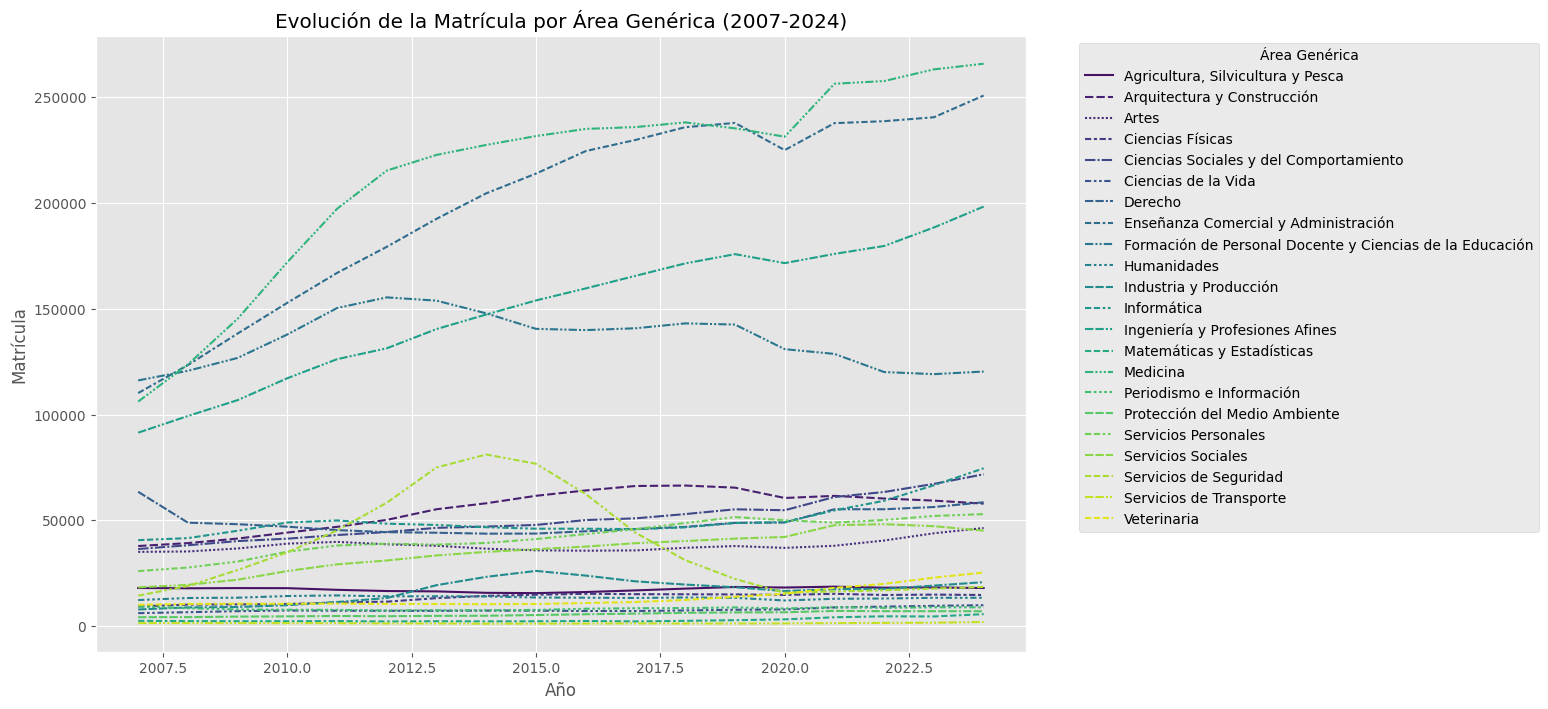

In [20]:
# Evolucion neta de las matriculas desde 2007 a 2024
plt.figure(figsize=(12, 8))
sns.lineplot(data=df_pivot, palette='viridis')
plt.title('Evolución de la Matrícula por Área Genérica (2007-2024)')
plt.xlabel('Año')
plt.ylabel('Matrícula')
plt.legend(title='Área Genérica', bbox_to_anchor=(1.05, 1))
plt.show()

Nota: Con el objetivo de evitar el efecto *"spaghetti chart"* y destacar las tendencias dominantes, se aislaron de forma individual las 4 áreas genéricas líderes y "Servicios de Seguridad" por su curva particular.

Para el resto de las áreas, debido a que no presentan un comportamiento homogéneo, se segmentaron en dos subgrupos diferenciados según su magnitud de demanda:

- Grupo Medio: Áreas con volumen de matrícula intermedio.

- Grupo Bajo: Áreas de nicho o menor volumen.

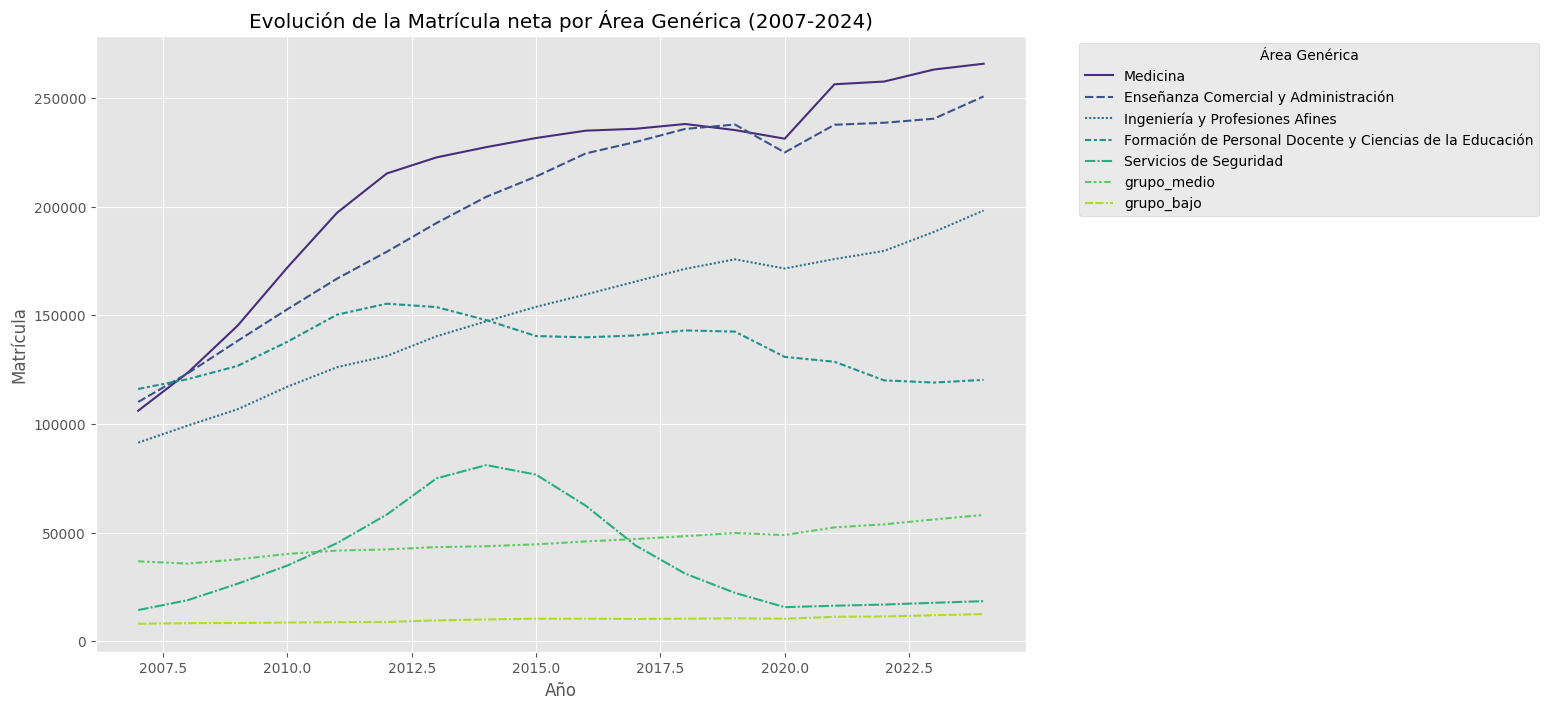

In [21]:
# Insights de la evolucion neta de las matriculas desde 2007 a 2024
grupo_medio = ["Arquitectura y Construcción",
               "Ciencias Sociales y del Comportamiento",
               "Informática",
               "Derecho",
               "Servicios Personales",
               "Servicios Sociales",
               "Artes"
               ]
grupo_bajo = ["Industria y Producción",
              "Agricultura, Silvicultura y Pesca",
              "Ciencias Físicas",
              "Humanidades",
              "Veterinaria",
              "Periodismo e Información",
              "Ciencias de la Vida",
              "Protección del Medio Ambiente",
              "Matemáticas y Estadísticas",
              "Servicios de Transporte"
              ]

df_insights = df_pivot[["Medicina",
                        "Enseñanza Comercial y Administración",
                        "Ingeniería y Profesiones Afines",
                        "Formación de Personal Docente y Ciencias de la Educación",
                        "Servicios de Seguridad"
                       ]].copy()

df_insights["grupo_medio"] = df_pivot.loc[:, grupo_medio].mean(axis=1)
df_insights["grupo_bajo"] = df_pivot.loc[:, grupo_bajo].mean(axis=1)

plt.figure(figsize=(12, 8))
sns.lineplot(data=df_insights, palette='viridis')
plt.title('Evolución de la Matrícula neta por Área Genérica (2007-2024)')
plt.xlabel('Año')
plt.ylabel('Matrícula')
plt.legend(title='Área Genérica', bbox_to_anchor=(1.05, 1))
plt.show()

*OBS 5: En este grafico de la evolución de la matricula separado por areas, se presentan 5 áreas y 2 grupos denominados "grupo_medio" y "grupo_bajo" para separar las tendencias de interés de los grupos con medio y bajo crecimiento.*

*Es posible apreciar que las áreas de Medicina y de Enseñanza Comercial y Administración han sido las lideres en estos ultimos 18 años, sin embargo en 2007, el área de Formacion de Personal Docente y Ciencias de la Educación era la que lideraba el ranking para despues quedar relegada en el 4to lugar  y con una tendencia desfavorable.*

*En el área de Servicios de Seguridad se aprecia un Boom & Bust el cual termina en 2020 y se encuentra cercana al grupo de bajo crecimiento*

*Por ultimo, el área de Ingeniería y Profesiones Afines registra una tendencia bastante rectilinea.*

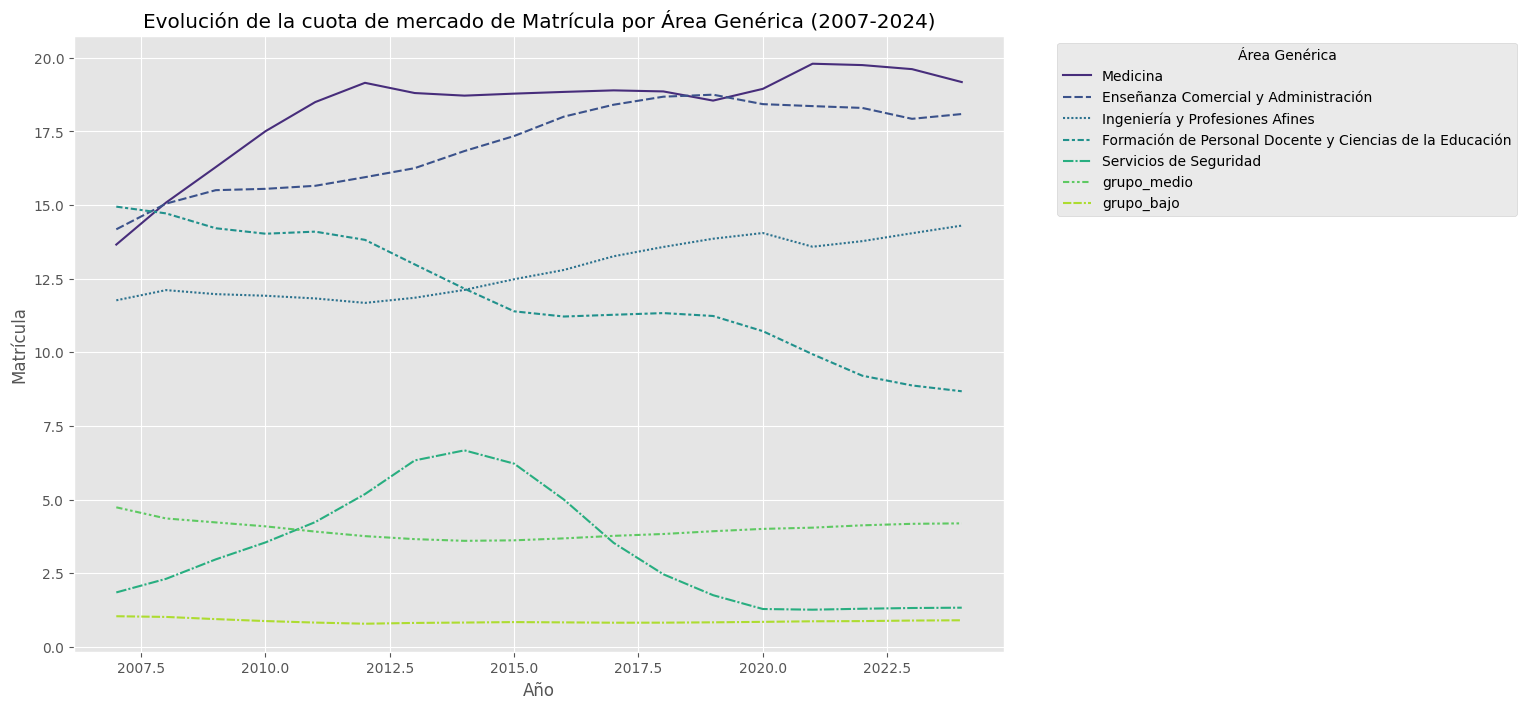

In [22]:
# Cuota de mercado de las matriculas desde 2007 a 2024
df_share = df_pivot.copy()
df_share = df_share.div(df_share.sum(axis=1), axis=0)
df_share = df_share.mul(100)

# Insights de Cuota de mercado de las matriculas desde 2007 a 2024
df_share_insights = df_share[["Medicina",
                              "Enseñanza Comercial y Administración",
                              "Ingeniería y Profesiones Afines",
                              "Formación de Personal Docente y Ciencias de la Educación",
                              "Servicios de Seguridad"
                              ]].copy()

df_share_insights["grupo_medio"] = df_share.loc[:, grupo_medio].mean(axis=1)
df_share_insights["grupo_bajo"] = df_share.loc[:, grupo_bajo].mean(axis=1)

plt.figure(figsize=(12, 8))
sns.lineplot(data=df_share_insights, palette='viridis')
plt.title('Evolución de la cuota de mercado de Matrícula por Área Genérica (2007-2024)')
plt.xlabel('Año')
plt.ylabel('Matrícula')
plt.legend(title='Área Genérica', bbox_to_anchor=(1.05, 1))
plt.show()

*OBS 6: Este gráfico de la cuota de mercado de cada periodo de matriculas concuerda con lo señalado en el gráfico de evolución neta, sin embargo a partir del año 2012 se observa una tendencia plana en el área de Medicina*

### IV. Conclusiones e Insights

##### 1. Evolución y Maduración del Sistema

* **El "Boom" y la Meseta:** Se observa un crecimiento explosivo entre **2008 y 2012**, impulsado por la masificación del acceso y nuevas herramientas de financiamiento (como el CAE). Sin embargo, a partir de 2012 el sistema entró en una fase de maduración y saturación, con un crecimiento mucho más moderado, alcanzando una tasa de crecimiento anual compuesto (**CAGR**) total de **3.46%**.
* **Resiliencia Post-Pandemia:** El punto de inflexión en **2020**, con una caída a **1.22M** de alumnos (equivalente a un **-3.8%** respecto al año anterior), se atribuye directamente a la crisis del COVID-19. Este fenómeno fue superado con éxito, alcanzando en **2024 un máximo histórico** que sugiere una recuperación total de la confianza en el sistema educativo y la adaptación a nuevas modalidades.

##### 2. Cambio de Liderazgo (2007 vs 2024)


*   **Caída de la docencia:** En 2007, el área de **Formación de Personal Docente** era la más grande del país. Hoy se encuentra estancada con niveles de matrícula casi idénticos a los de hace 17 años, perdiendo drásticamente cuota de mercado y quedando relegada al **4to lugar** de las preferencias. Esta disminución responde a factores como el incremento de exigencias de ingreso, el cierre de programas de baja calidad y el desgaste de la profesión (alto estrés, carga laboral e incentivos económicos limitados).
*   **El ascenso de Salud y Negocios:** **Medicina** y **Enseñanza Comercial y Administración** son los nuevos pilares. El área de salud ha crecido un **150.5%**, reflejando una demanda social constante. El área Comercial, por su parte, es concordante con la estructura económica de Chile enfocada en **servicios** (retail, banca e inmobiliaria), lo que ha empujado las matrículas de forma masiva.
*   **¿Y las Ingenierías?:** El área de **Ingeniería y Profesiones Afines** ha crecido un **116.9%** de manera casi ininterrumpida. No obstante, dado que el potencial industrial de Chile se concentra mayoritariamente en la minería, surge una incertidumbre estratégica sobre si el país podrá **absorber** esta oferta de ingenieros en el futuro.

##### 3. Ganadores y Perdedores en el Mercado Laboral

*   **Áreas en Auge:** **Industria y Producción** lidera el crecimiento relativo (**164.5%**), seguida de cerca por Veterinaria y Medicina. Esto indica un fuerte desplazamiento de la inversión estudiantil hacia carreras técnicas especializadas y de salud.
*   **Saturación y Decrecimiento:** Las áreas de **Derecho (-7.8%)** y **Periodismo e Información (-4.1%)** son las únicas con crecimiento negativo sostenido. Esto sugiere una corrección del mercado ante la sobreoferta de profesionales y una baja en la percepción de rentabilidad de estas disciplinas.
*   **Ciclos de Especialidad:** El caso de **Servicios de Seguridad (Prevención de Riesgos)** es un ejemplo de manual de "boom y caída". Un cambio normativo disparó la demanda inicial, pero la respuesta masiva de las instituciones (IP y CFT) saturó el mercado laboral en pocos años, frenando bruscamente la tendencia al alza.

##### 4. Reflexión Estratégica: ¿Saturación de Servicios?

Chile se consolida como un país enfocado en el sector servicios. El alto volumen de matrícula en **Administración e Ingenierías** plantea el desafío de la absorción laboral. Existe un riesgo latente de **subempleabilidad** si la matriz productiva del país no evoluciona al mismo ritmo que la formación académica; estos profesionales podrían terminar ocupando puestos de gestión que requieren una calificación técnica menor a la obtenida en sus estudios.

## **Business Objective 2:** ¿Qué tipo de instituciones eligen los estudiantes?

Como segundo objetivo, se busca identificar los tipos de instituciones (Universidades vs. IP/CFT) que han capturado la mayor parte del crecimiento de la matrícula.

Para responder esto, se utilizarán las variables `cat_periodo`, `tipo_inst_1`, `tipo_inst_2` y `nivel_carrera_2`.

Solo se seleccionaron 2 de las 3 variables relacionadas al tipo de institucion, `tipo_inst_1` y `tipo_inst_2`, debido a que se considera que `tipo_inst_3` brinda categorías mucho mas amplias y que no son tan utiles para este análisis.

Del mismo modo, para relacionar los niveles específicos al que pertenecen los programas de estudio, sólo se seleccionó `nivel_carrera_2` debido a que su clasificación es mucho mas general que `nivel_carrera_1`.

**Recursos:**
- [Consulta SQL](https://github.com/FeliProjects/analisis-educacion-superior-chile/blob/main/sql/03_bo2_tipo_institucion.sql)
- [Dataset](https://github.com/FeliProjects/analisis-educacion-superior-chile/blob/main/data/processed/bo_2_dataset.csv)

### I. Preparación y Transformación de Datos

In [23]:
# Carga de datos para el BO2
bo2_file_path = BASE_PATH / "bo_2_dataset.csv"

df_inst = pd.read_csv(bo2_file_path)
df_inst.drop(columns=['Unnamed: 0'], inplace=True)
df_inst['cat_periodo'] = df_inst['cat_periodo'].astype(int)

In [24]:
# Exploración del DataFrame
print("INFO")
print(df_inst.info())

INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   cat_periodo      286 non-null    int64 
 1   tipo_inst_1      286 non-null    object
 2   tipo_inst_2      286 non-null    object
 3   nivel_carrera_2  286 non-null    object
 4   total_alumnos    286 non-null    int64 
dtypes: int64(2), object(3)
memory usage: 11.3+ KB
None


El dataset es bastante acotado con 286 registros y sin valores nulos.

In [25]:
# Pivotear la tabla para tener los años como índice y las áreas tipo_inst_1 como columnas
df_pivot_inst_1 = df_inst.pivot_table(index='cat_periodo',
                              columns='tipo_inst_1',
                              values='total_alumnos',
                              aggfunc='sum')

# df_pivot_inst_1 # Descomentar en caso de querer ver el DF

In [26]:
# Pivotear la tabla para tener los años como índice y las áreas tipo_inst_2 como columnas
df_pivot_inst_2 = df_inst.pivot_table(index='cat_periodo',
                              columns='tipo_inst_2',
                              values='total_alumnos',
                              aggfunc='sum')

df_pivot_inst_2

tipo_inst_2,Centros de Formación Técnica,Institutos Profesionales,Universidades (* Carrera en Convenio),Universidades CRUCH,Universidades Privadas
cat_periodo,,,,,
2007,86838.0,156124.0,NaN,285984.0,247892.0
2008,95903.0,162870.0,NaN,295158.0,265866.0
2009,110021.0,189622.0,NaN,303127.0,288949.0
2010,128508.0,224339.0,NaN,310890.0,318883.0
2011,138524.0,267766.0,NaN,309333.0,350720.0
2012,139962.0,301156.0,NaN,311775.0,371340.0
2013,144383.0,332147.0,NaN,326040.0,381801.0
2014,148012.0,357395.0,NaN,333549.0,376174.0
2015,146546.0,378802.0,NaN,336707.0,370988.0


La variable `Universidades (* Carrera en Convenio)` corresponde a estudiantes que fueron reubicados debido a que la institución de educación superior en la que estaban, cerró

Son convenios suscritos entre el Ministerio de Educación (Mineduc) y distintas universidades para que los estudiantes de planteles en crisis pudieran finalizar sus estudios en instituciones vigentes.

### II. Análisis de instituciones

In [27]:
# Obtener el Crecimiento Absoluto por tipo_inst_1
df_growth_inst_1 = df_pivot_inst_1.loc[2024] - df_pivot_inst_1.loc[2007]

# ¿Quién capturó el crecimiento?
total_growth_inst_1 = df_growth_inst_1.sum()

df_share_inst_1 = (df_growth_inst_1 / total_growth_inst_1) * 100

# Resultado final
df_resultado_inst_1 = pd.DataFrame({
    'crecimiento_absoluto': df_growth_inst_1,
    'participacion_crecimiento_%': df_share_inst_1
}).sort_values(by='participacion_crecimiento_%', ascending=False)

df_resultado_inst_1

,crecimiento_absoluto,participacion_crecimiento_%
tipo_inst_1,,
Universidades,280374,46.019759
Institutos Profesionales,270407,44.383805
Centros de Formación Técnica,58466,9.596436


In [28]:
# Crecimiento Absoluto por tipo_inst_2
df_growth_inst_2 = df_pivot_inst_2.loc[2024] - df_pivot_inst_2.loc[2007]

# ¿Quién capturó el crecimiento?
total_growth_inst_2 = df_growth_inst_2.sum()

df_share_inst_2 = (df_growth_inst_2 / total_growth_inst_2) * 100

# Resultado final
df_resultado_inst_2 = pd.DataFrame({
    'crecimiento_absoluto': df_growth_inst_2,
    'participacion_crecimiento_%': df_share_inst_2
}).sort_values(by='participacion_crecimiento_%', ascending=False)

#print(df_resultado_inst_2)
df_resultado_inst_2

,crecimiento_absoluto,participacion_crecimiento_%
tipo_inst_2,,
Institutos Profesionales,270407.0,44.392184
Universidades CRUCH,171611.0,28.173040
Universidades Privadas,108648.0,17.836528
Centros de Formación Técnica,58466.0,9.598248
Universidades (* Carrera en Convenio),NaN,NaN


In [29]:
# Calculo CAGR por tipo de institucion
def calculate_cagr(df, initial_year, final_year):
    initial_value = df.loc[initial_year]
    final_value = df.loc[final_year]
    years = final_year - initial_year
    cagr = ((final_value / initial_value) ** (1/years) - 1) * 100
    return cagr

# Aplicar la función a cada DataFrame
cagr_inst_1 = calculate_cagr(df_pivot_inst_1, 2007, 2024)
cagr_inst_2 = calculate_cagr(df_pivot_inst_2, 2007, 2024)

# Crear un nuevo DataFrame con los resultados
df_cagr_inst_1 = pd.DataFrame({
    'cagr': cagr_inst_1
}).sort_values(by='cagr', ascending=False)

df_cagr_inst_2 = pd.DataFrame({
    'cagr': cagr_inst_2
}).sort_values(by='cagr', ascending=False)

print(df_cagr_inst_1.to_markdown()+ '\n')
print(df_cagr_inst_2.to_markdown())

| tipo_inst_1                  |    cagr |
|:-----------------------------|--------:|
| Institutos Profesionales     | 6.09022 |
| Centros de Formación Técnica | 3.07445 |
| Universidades                | 2.51405 |

| tipo_inst_2                           |      cagr |
|:--------------------------------------|----------:|
| Institutos Profesionales              |   6.09022 |
| Centros de Formación Técnica          |   3.07445 |
| Universidades CRUCH                   |   2.80357 |
| Universidades Privadas                |   2.16098 |
| Universidades (* Carrera en Convenio) | nan       |


In [30]:
# Calculo CAGR Total
df_cagr = df_inst.copy()
df_cagr = df_cagr[['cat_periodo', 'total_alumnos']]
df_cagr = df_cagr.groupby('cat_periodo').sum()

cagr_total = calculate_cagr(df_cagr['total_alumnos'], 2007, 2024)

print(f"La matrícula total creció un {cagr_total:.2f}% anual compuesto.")

La matrícula total creció un 3.46% anual compuesto.


*OBS 1: En en análisis de la Tasa de Crecimiento Anual Compuesto (CAGR) es posible observar que la tasa global fue de 3.46%, sin embargo los Institutos Profesionales casi duplicaron ese valor con una tasa del 6.1%. Este comportamiento evidencia un dinamismo muy superior al de las universidades (2.5%) y CFT (3.1%)*

### III. Análisis de Tendencias y Categorías

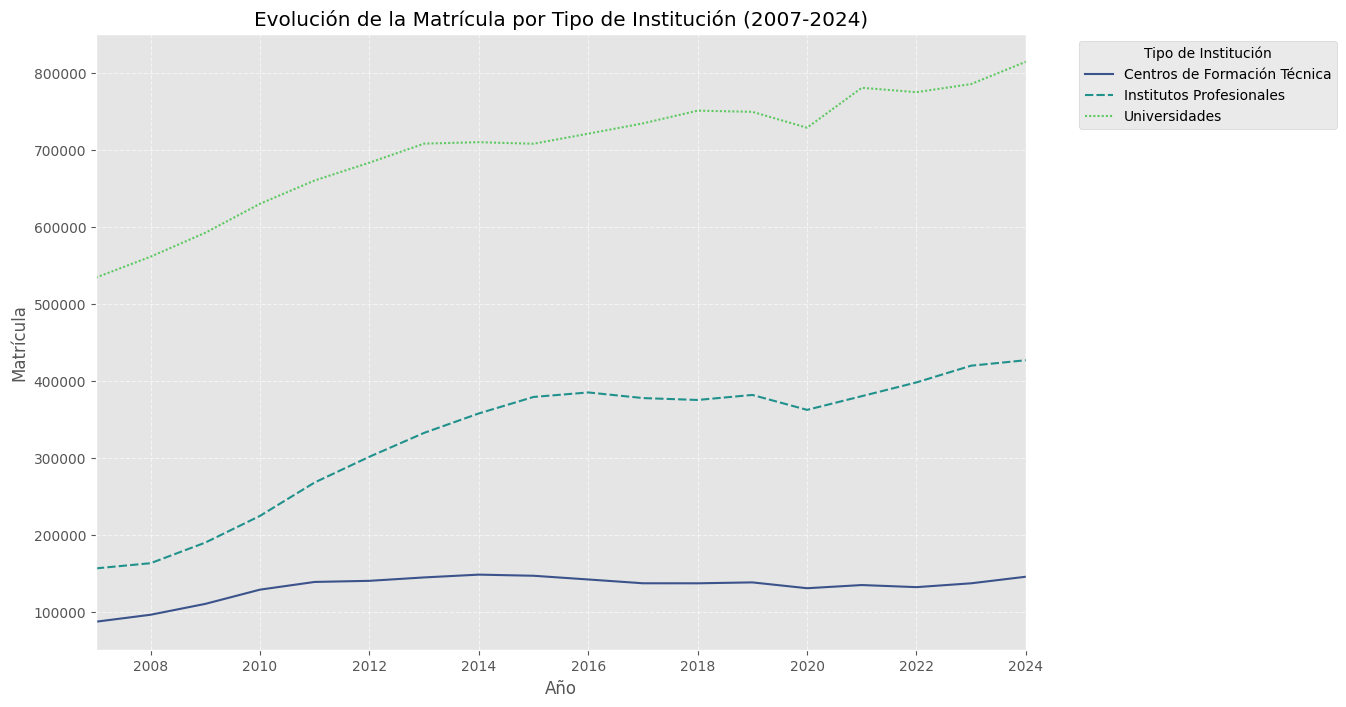

In [31]:
# Plot 1 Evolución de Matriculas por tipo_inst_1

plt.figure(figsize=(12, 8))
sns.lineplot(data=df_pivot_inst_1, palette='viridis')
plt.title('Evolución de la Matrícula por Tipo de Institución (2007-2024)')
plt.xlabel('Año')
plt.ylabel('Matrícula')
plt.legend(title='Tipo de Institución', bbox_to_anchor=(1.05, 1))
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(2007, 2024)
plt.show()

*OBS 2: Históricamente, las universidades se mantienen como las instituciones con mayor volumen absoluto de estudiantes, consolidando su posición como la opción mayoritaria en el sistema chileno. No obstante, al cruzar el volumen con el CAGR, se hace evidente que los Institutos Profesionales han traccionado una parte significativa de la demanda, logrando casi triplicar su matrícula neta entre 2007 y 2024 (pasando de 156 mil a más de 426 mil estudiantes).*

*Un punto importante es que las carreras universitarias son más largas y el sistema va "acumulando" estudiantes por un periodo de tiempo superior*

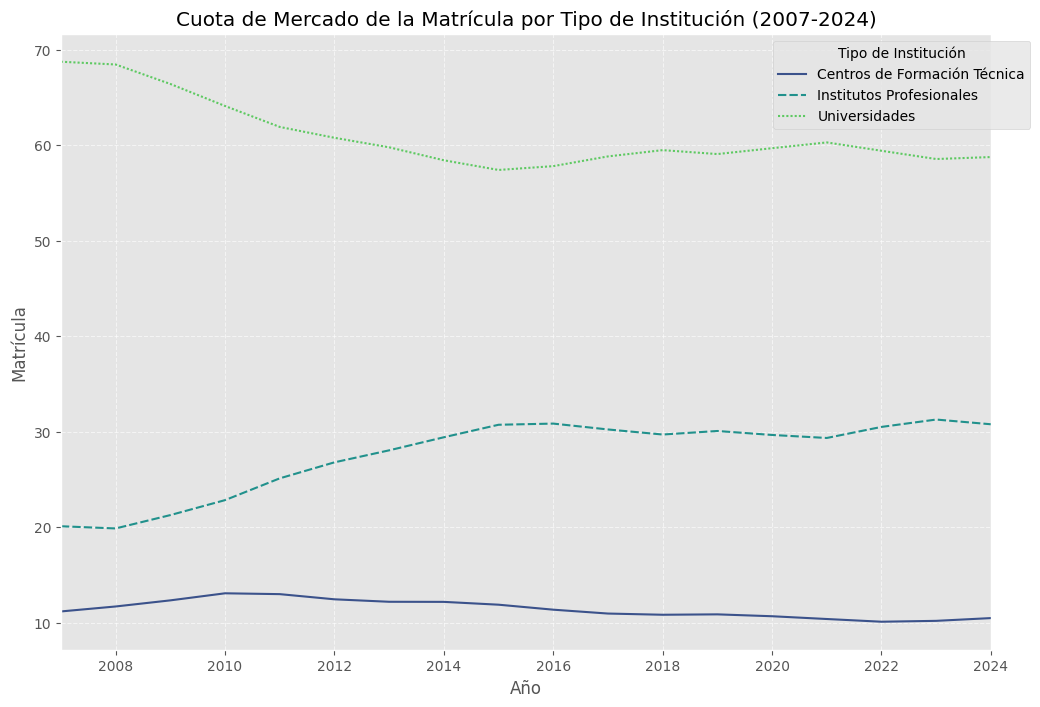

In [32]:
# Plot 2 Analisis Cuota de Mercado por tipo de institución (tipo_inst_1)
df_mkt_share = df_pivot_inst_1.copy()
df_mkt_share = df_mkt_share.div(df_mkt_share.sum(axis=1), axis=0)
df_mkt_share = df_mkt_share.mul(100)

plt.figure(figsize=(12, 8))
sns.lineplot(data=df_mkt_share, palette='viridis')
plt.title('Cuota de Mercado de la Matrícula por Tipo de Institución (2007-2024)')
plt.xlabel('Año')
plt.ylabel('Matrícula')
plt.legend(title='Tipo de Institución', bbox_to_anchor=(1.05, 1))
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(2007, 2024)
plt.show()

*OBS 3: En el análisis de la cuota de mercado (Market Share) de cada institucion, es posible ver graficamente como han ido cambiando las preferencias de los estudiantes, donde los IP han gandado un 10.7% de la cuota de mercado a las Universidades. A pesar de estos cambios, las universidades siguen manteniendo la mayoria de los estudiantes del sistema.*

*El fenómeno de los CFT es bastante interesante porque su cuota de mercado ha mantenido estable en todo este tiempo con un ~10% de las preferencias, en un área donde muchas veces se topan con los IP*

Para profundizar más en el analisis, se abrirá la categoria Universidades para separarlas en Ues del CRUCH (Consejo de Rectores Universidades Chilenas) y Ues Privadas

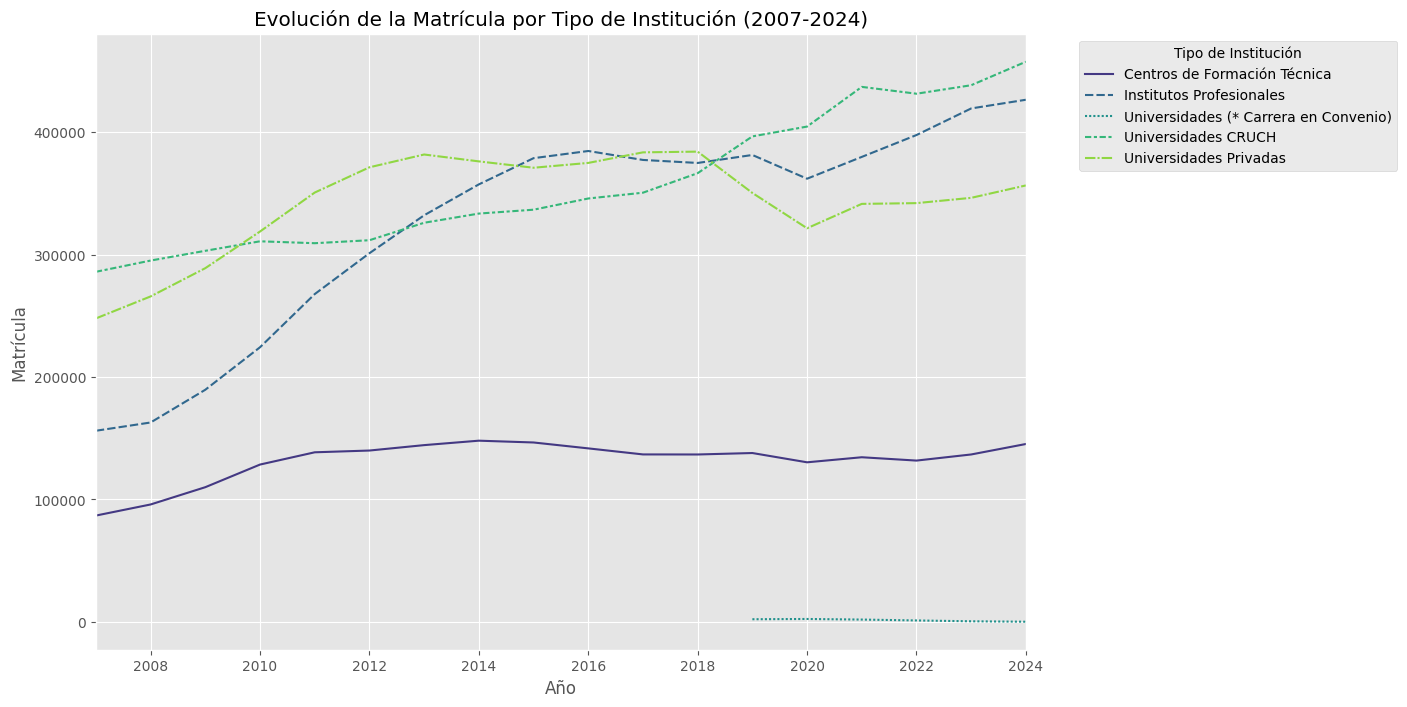

In [33]:
# # Plot 3 Evolución de Matriculas por tipo_inst_2

plt.figure(figsize=(12, 8))
sns.lineplot(data=df_pivot_inst_2, palette='viridis')
plt.title('Evolución de la Matrícula por Tipo de Institución (2007-2024)')
plt.xlabel('Año')
plt.ylabel('Matrícula')
plt.legend(title='Tipo de Institución', bbox_to_anchor=(1.05, 1))
plt.xlim(2007, 2024)
plt.show()

*OBS 4: Al desagrupar los tipos de universidades, es posible observar una mayor competitividad entre todas las instituciones del sistema de educación superior chileno.*

*El crecimiento de los Institutos Profesionales (CAGR de 6.09%) no solo duplica el ritmo de los Centros de Formación Técnica (3.07%) y de las universidades tradicionales del CRUCH (2.80%), sino que casi triplica la velocidad de expansión de las Universidades Privadas (2.16%)*

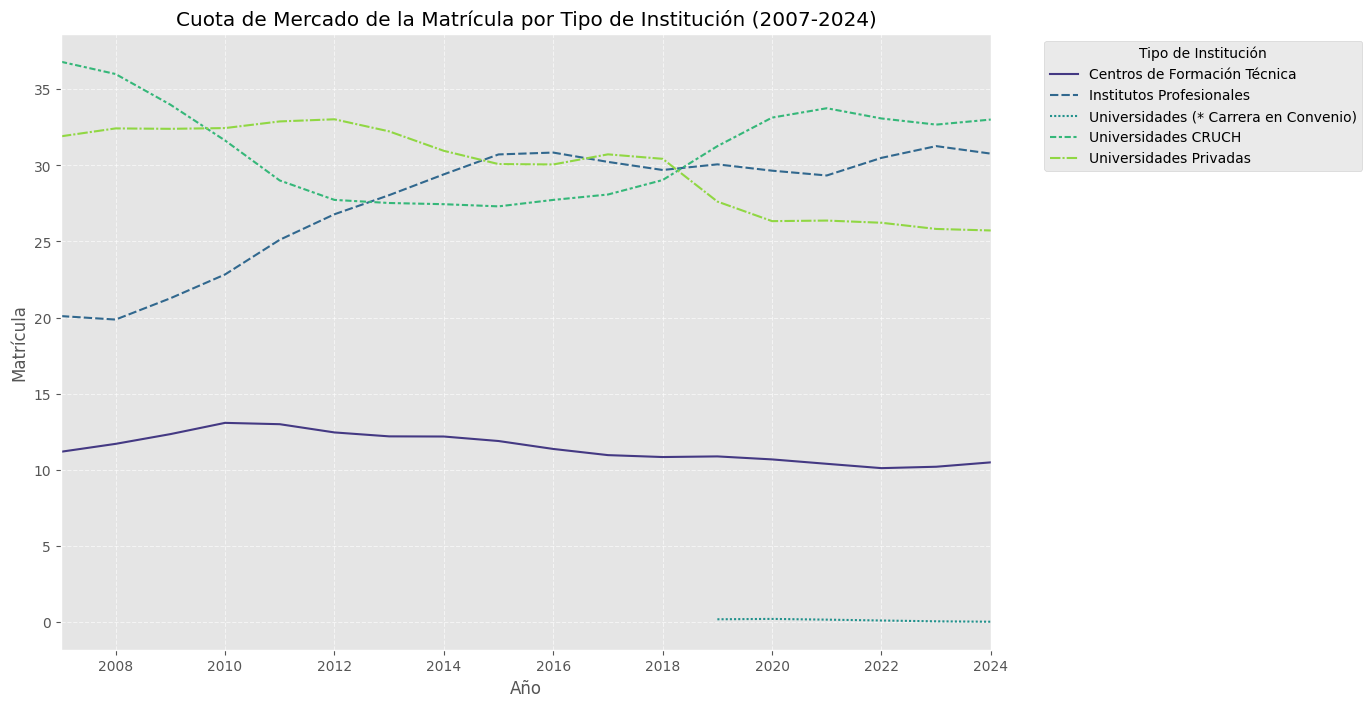

In [34]:
# Plot 4 Analisis Cuota de Mercado por tipo de institución (tipo_inst_2)
df_mkt_share_2 = df_pivot_inst_2.copy()
df_mkt_share_2 = df_mkt_share_2.div(df_mkt_share_2.sum(axis=1), axis=0)
df_mkt_share_2 = df_mkt_share_2.mul(100)

plt.figure(figsize=(12, 8))
sns.lineplot(data=df_mkt_share_2, palette='viridis')
plt.title('Cuota de Mercado de la Matrícula por Tipo de Institución (2007-2024)')
plt.xlabel('Año')
plt.ylabel('Matrícula')
plt.legend(title='Tipo de Institución', bbox_to_anchor=(1.05, 1))
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(2007, 2024)
plt.show()

*OBS 5: El subsector de las Universidades Privadas es señalado como el principal afectado, experimentando un retroceso al caer del segundo al tercer lugar en participación de mercado (contrayéndose del 31.91% al 25.72%). Este fenómeno se alinea temporalmente con factores regulatorios y reputacionales críticos en Chile, tales como las crisis de viabilidad y cierres de varias instituciones privadas, sumado al posterior endurecimiento de los estándares del Sistema Nacional de Acreditación. Adicionalmente, estos hitos instalaron un manto de duda sobre la calidad de ciertas casas de estudio de este bloque, afectando severamente la confianza pública y la atracción de nuevas matrículas.*

*OBS 6: El periodo 2007-2024 consolidó un cambio de posiciones histórico en el ordenamiento de la educación superior. En 2007, los IP ocupaban un tercer lugar con el 20.09% de la matrícula total. Hacia 2024, los IP no solo escalaron al segundo lugar del sistema con un 30.77%, sino que desplazaron a las universidades privadas y se posicionaron a una distancia mínima (menos del 2%) de alcanzar al bloque dominante de las universidades del CRUCH (32.68%)*

### IV. Análisis complementario: 1er año

Con este análisis, se busca complementar el análisis del crecimiento de matrícula total con la evaluación de las matrículas de primer año, para identificar qué tipo de institución capta más estudiantes nuevos en cada cohorte, para poder aislar el efecto de la duración real de las carreras.

**Recursos:**
- [Consulta SQL](https://github.com/FeliProjects/analisis-educacion-superior-chile/blob/main/sql/04_bo2_primer_a%C3%B1o.sql)
- [Dataset](https://github.com/FeliProjects/analisis-educacion-superior-chile/blob/main/data/processed/bo_2_dataset_primer_a%C3%B1o.csv)

In [35]:
# Carga de datos para el análisis complementario

bo2_primer_año_file_path = BASE_PATH / "bo_2_dataset_primer_año.csv"

df_primer_año = pd.read_csv(bo2_primer_año_file_path)
df_primer_año.drop(columns=['Unnamed: 0'], inplace=True)

df_primer_año.head()

,cat_periodo,tipo_inst_1,tipo_inst_2,total_alumnos
0,2007,Centros de Formación Técnica,Centros de Formación Técnica,43912
1,2007,Institutos Profesionales,Institutos Profesionales,68128
2,2007,Universidades,Universidades CRUCH,69426
3,2007,Universidades,Universidades Privadas,74853
4,2008,Centros de Formación Técnica,Centros de Formación Técnica,47068


In [36]:
# Exploración del DataFrame
print("INFO")
print(df_primer_año.info())

INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   cat_periodo    72 non-null     int64 
 1   tipo_inst_1    72 non-null     object
 2   tipo_inst_2    72 non-null     object
 3   total_alumnos  72 non-null     int64 
dtypes: int64(2), object(2)
memory usage: 2.4+ KB
None


In [37]:
# Tabla pivote entre cat_periodo y tipo_inst_2
df_pivot_primer_año = df_primer_año.pivot_table(index='cat_periodo',
                              columns='tipo_inst_2',
                              values='total_alumnos',
                              aggfunc='sum')

df_pivot_primer_año

tipo_inst_2,Centros de Formación Técnica,Institutos Profesionales,Universidades CRUCH,Universidades Privadas
cat_periodo,,,,
2007,43912,68128,69426,74853
2008,47068,68734,71219,83049
2009,53216,81204,73440,92678
2010,63088,95221,75860,100354
2011,64036,105762,73120,102174
2012,62576,111783,73363,102415
2013,64740,127867,77892,96098
2014,65945,130002,79435,90405
2015,63557,125795,83326,89967


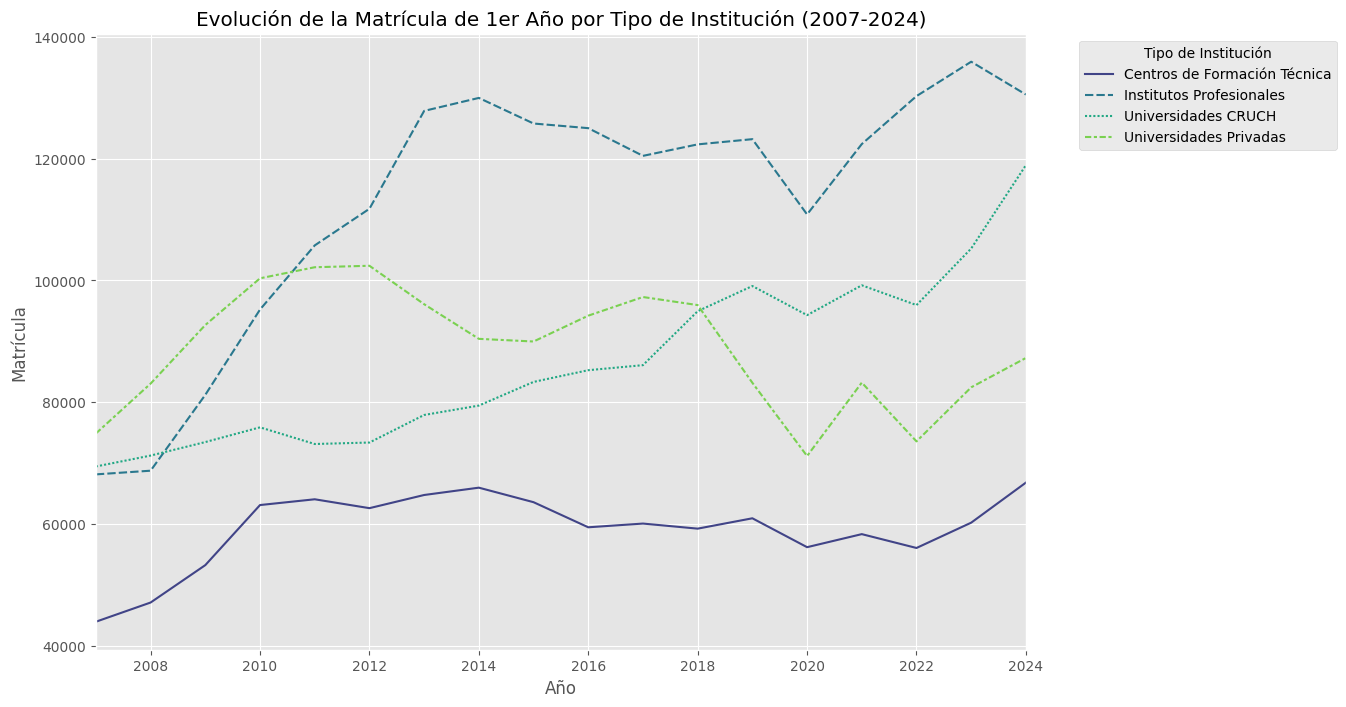

In [38]:
# Plot 1 Evolución de la Matrícula de 1er Año por Tipo de Institución tipo_inst_2

plt.figure(figsize=(12, 8))
sns.lineplot(data=df_pivot_primer_año, palette='viridis')
plt.title('Evolución de la Matrícula de 1er Año por Tipo de Institución (2007-2024)')
plt.xlabel('Año')
plt.ylabel('Matrícula')
plt.legend(title='Tipo de Institución', bbox_to_anchor=(1.05, 1))
plt.xlim(2007, 2024)
plt.show()

*OBS 7: De acuerdo a este gráfico, las diferencias no parecen tan grandes. Es posible apreciar que desde 2011, los IP lideran las matriculas de primer año. Tambien muestra que a las Ues Privadas no han podido recuperar el volumen de matriculas registradas antes de 2018, en cambio las Ues del CRUCH presentan una tendencia al alza que ya casi alcanza a las matriculas registradas por los IP. Finalmente, los CFT presentan una tendencia lateral*

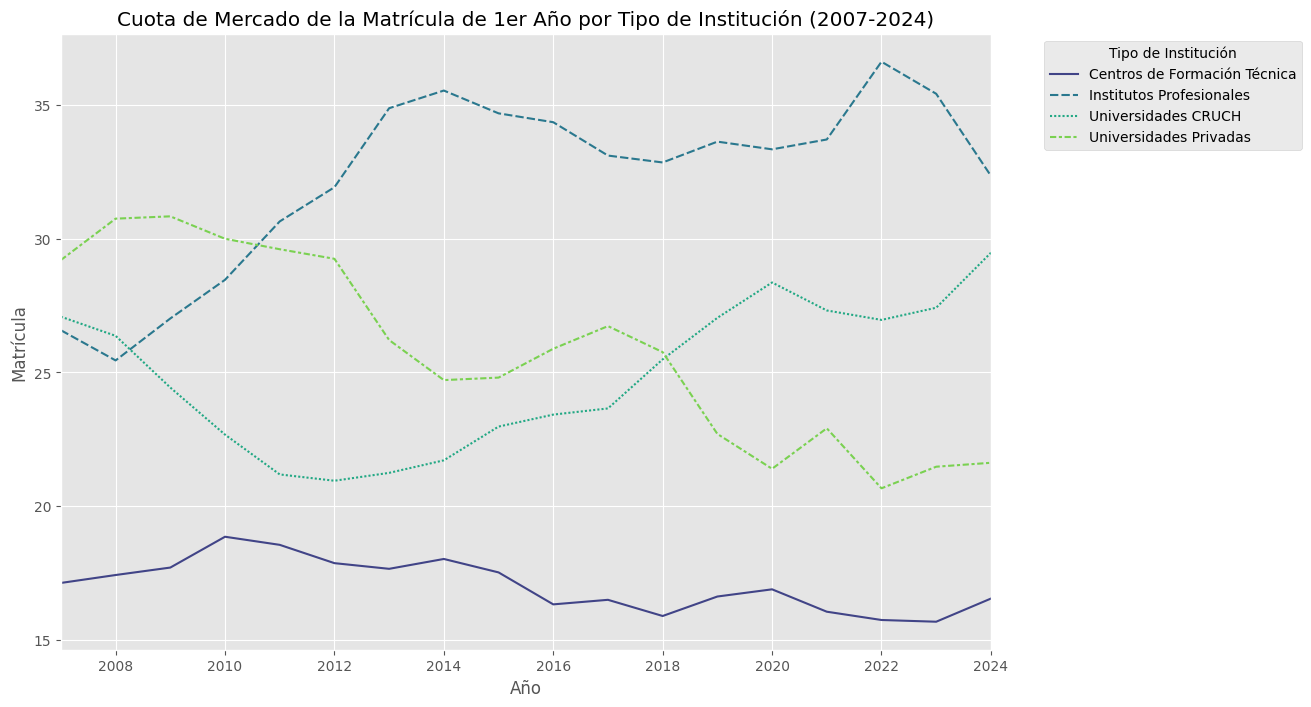

In [39]:
# Cuota de mercado 1er año
df_share_primer_año = df_pivot_primer_año.copy()
df_share_primer_año = df_share_primer_año.div(df_share_primer_año.sum(axis=1), axis=0)
df_share_primer_año = df_share_primer_año.mul(100)

# Plot 2 Cuota de Mercado de la Matrícula de 1er Año por Tipo de Institución tipo_inst_2
plt.figure(figsize=(12, 8))
sns.lineplot(data=df_share_primer_año, palette='viridis')
plt.title('Cuota de Mercado de la Matrícula de 1er Año por Tipo de Institución (2007-2024)')
plt.xlabel('Año')
plt.ylabel('Matrícula')
plt.legend(title='Tipo de Institución', bbox_to_anchor=(1.05, 1))
plt.xlim(2007, 2024)
plt.show()

In [40]:
# Cuota de Mercado total de universidades (CRUCH + Privadas)
df_share_primer_año['total_ues'] = df_share_primer_año['Universidades CRUCH'] + df_share_primer_año['Universidades Privadas']
df_share_primer_año

tipo_inst_2,Centros de Formación Técnica,Institutos Profesionales,Universidades CRUCH,Universidades Privadas,total_ues
cat_periodo,,,,,
2007,17.131777,26.579380,27.085780,29.203063,56.288843
2008,17.428074,25.450439,26.370571,30.750916,57.121487
2009,17.706912,27.019545,24.436178,30.837365,55.273543
2010,18.859092,28.464709,22.677066,29.999133,52.676199
2011,18.556211,30.647480,21.188553,29.607757,50.796309
2012,17.871862,31.925503,20.952656,29.249979,50.202635
2013,17.659719,34.879445,21.247310,26.213526,47.460836
2014,18.028251,35.540355,21.716190,24.715203,46.431393
2015,17.525955,34.688194,22.977292,24.808559,47.785851


In [41]:
# CAGR Primer Año
cagr_primer_año = calculate_cagr(df_pivot_primer_año, 2007, 2024)

df_cagr_primer_año = pd.DataFrame({
    'cagr': cagr_primer_año
}).sort_values(by='cagr', ascending=False)

print(df_cagr_primer_año.to_markdown())

total_primer_año = df_primer_año.copy()
total_primer_año = total_primer_año[['cat_periodo', 'total_alumnos']]
total_primer_año = total_primer_año.groupby('cat_periodo').sum()

print(f'CAGR Total 1er Año: {calculate_cagr(total_primer_año, 2007, 2024).loc['total_alumnos']}')

| tipo_inst_2                  |     cagr |
|:-----------------------------|---------:|
| Institutos Profesionales     | 3.9      |
| Universidades CRUCH          | 3.218    |
| Centros de Formación Técnica | 2.49627  |
| Universidades Privadas       | 0.906507 |
CAGR Total 1er Año: 2.7057389096294404


*OBS 8:Con estas tasas de crecimiento anual compuesto (CAGR) es posible ver que las Ues del CRUCH (CAGR de 3.2%) tuvieron un ritmo de crecimiento que triplica a las Ues Privadas (0.9%).*

*Tambien se aprecia que la tasa de crecimiento de matriculas de estudiantes de primer año (CAGR 2.7%) es menor que la tasa de crecimiento total (CAGR 3.5%), por lo que parte del aumento de las matriculas es explicada por la duración de los programas.*

### V. Conclusiones e Insights

#### 1. Diferentes ritmos de crecimiento

* A continuación se presenta una tabla con las tasas de crecimiento para cada institución.
|Institución|CAGR Total|CAGR 1er Año|Δ CAGR|
|-|-|-|-|
|IP|6.1%|3.9%|2.2%|
|CFT|3.1%|2.5%|0.6%|
|Ues CRUCH|2.8%|3.2%|-0.4%|
|Ues Privadas|2.2%|0.9%|1.3%|
|Total|3.5%|2.7%|0.8%|

    <img src ="https://raw.githubusercontent.com/FeliProjects/analisis-educacion-superior-chile/refs/heads/main/assets/imagenes/02_cagr.png" width=700 height=440>
    

*   **IP, los grandes ganadores:** Son el motor de crecimiento del sistema. Lideran tanto en la tasa de crecimiento de estudiantes del primer año (CAGR 3.9%) como en la permanencia de estos (Δ CAGR 2.2%). Esto indica que son instituciones que crecen mucho en captación de estudiantes nuevos y en la permanencia de estos estudiantes.

* **CFT, los mas equilibrados:** Estas instituciones presentan un crecimiento moderado y balanceado con respecto al resto,  con un Δ CAGR 0.6%. Debido a la duración de sus programas, la tasa de crecimiento total con respecto a los de primer año, no varía mucho.

* **Las Ues del CRUCH dominan frente a las Privadas:** Las Universidades del CRUCH tienen tasas de crecimiento superiores que sus rivales de las Ues Privadas (3.2% vs. 0.9%), sin embargo son las unicas que tienen un Δ CAGR negativo (-0.4%), esto indica que su base de crecimiento esta ligeramente inclinada por los estudiantes nuevos (alta demanda) y no tanto por los que permanecen en la institución. Por otro lado, las Ues Privadas son las que menos crecen, pero son capaces de retener mas tiempo a los estudiantes que las Universidades del CRUCH.

#### 2. Cuotas de Mercado

* **Ues vs el resto:** Tanto en matriculas totales como en matriculas de primer año, las universidades capturan la mayoria de los estudiantes. Esto podria suponer desafíos para los futuros profesionales que podrían enfrentar problemas de sub-empleo y una feroz competencia en las postulaciones.

* **CRUCH vs IP:** Que en 2024, los IP estén 1.9% por debajo en las matriculas totales, indica que el ecosistema se encuentra en una etapa de doble hegemonía, lo que posiciona a los IP como una alternativa legítima, con programas más cortos, flexibles y orientados al mercado laboral.

* **Sinergia IP-Universidad:** Algunos IP son parte de universidades (como AIEP de la Universidad Andrés Bello o Duoc UC de la Pontificia Universidad Católica de Chile), lo que otorga prestigio, legitimidad y la posibilidad de continuar con estudios hacia grados superiores.

###### 3. Confianza institucional y programas sociales

* **Ues Privadas con baja confianza:** Las Universidades Privadas pueden ser catalogadas como las grandes perdedoras en el análisis 2007 - 2024, debido a que fueron superadas ampliamente por las Ues del CRUCH y los IP. El efecto de la crisis de la educación superior se asoma como uno de los principales responsables de esta caida.

* **Programas sociales y becas:** A pesar de la perdida de confianza y caida en la participación en el sistema eduacional, algunas Universidades Privadas han respondido con diferentes estrategias, diferenciandose de las Ues del CRUCH:

    * **Becas:** Ofrecen mejores condiciones económicas a estudiantes con altos puntajes en las pruebas de selección universitaria, superando las propuestas de las Ues del CRUCH. Este es un punto vital para estudiantes de buen desempeño pero de bajos recursos.
    * **Captación de talento:** Las Ues del CRUCH pueden darse el lujo de rechazar a buenos estudiantes por no brindar mejores condiciones o seguridades económicas.

* **Cuestionamientos:** A pesar de los intentos por reconstruir la legitimidad en sus instituciones, cabe preguntarse si estas iniciativas son suficienctes para revertir la caida en sus matriculas.

#### 4. Consideraciones futuras

* **Δ CAGR negativo en Ues del CRUCH:** Debido al Δ CAGR negativo de las Ues del CRUCH (-0.4%), se abre la posibilidad de analizar las tasas de retención, titulación y deserción de los estudiantes. Ese análisis podría aportar insights valiosos que permitan entender si corresponde a una deserción temprana o a un egreso a tiempo.

* **Duración de las carreras:** Analizar la duración teórica y real de los programas podría explicar diferencias en el Δ CAGR y aportar a la discusión sobre eficiencia y resultados del sistema. Esto permitiría evaluar el costo financiero que asume el Estado de Chile (vía grauidad) y las familias chilenas (vía CAE o Crédito Institucional o auto-financiamento)

* **Futuro profesional:** El predominio de las universidades frente a los IP y CFT podría derivar en un exceso de profesionales universitarios frente a los técnicos. Esto podría tener implicancias en distintas areas, tales como la empleabilidad, frustración y emigración de profesionales.

## **Business Objective 3:** ¿Qué programas académicos incrementaron su relevancia en este periodo?

El tercer Business Objective busca identificar carreras emergentes que presentaban una baja relevancia en 2007 pero que ahora han consolidado una alta demanda.

Se seleccionaron las variables `cat_periodo`, `cine_f_13_subarea` y `cine_f_13_area`.
Se detectó que la información de estas dos ultimas categorías estan intercambiadas, en la cual `cine_f_13_area` describe carreras de forma mucho mas especificas que `cine_f_13_subarea`.

**Recursos:**
- [Consulta SQL](https://github.com/FeliProjects/analisis-educacion-superior-chile/blob/main/sql/05_bo3_carreras_emergentes.sql)
- [Dataset](https://github.com/FeliProjects/analisis-educacion-superior-chile/blob/main/data/processed/bo_3_dataset.csv)

### I. Preparación y Transformación de Datos

In [42]:
# Carga de datos para el BO3
bo3_file_path = BASE_PATH / "bo_3_dataset.csv"

df_carreras = pd.read_csv(bo3_file_path)

df_carreras.sample(2)

,cat_periodo,sector_macro,familia_carrera,total_alumnos
1887,2012,"Ingeniería, Industria y Construcción",Ingeniería Civil en Sonido y Acústica,202
4510,2020,Artes y Humanidades,Técnico en Producción de Videojuegos,48


In [43]:
# Exploración del DataFrame
print("INFO")
df_carreras.info()

INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6060 entries, 0 to 6059
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   cat_periodo      6060 non-null   int64 
 1   sector_macro     6060 non-null   object
 2   familia_carrera  6060 non-null   object
 3   total_alumnos    6060 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 189.5+ KB


In [44]:
# Normalización de nombres (para búsquedas consistentes)
df_carreras['familia_carrera'] = (
    df_carreras['familia_carrera']
    .str.normalize('NFKD')
    .str.encode('ascii', errors='ignore')
    .str.decode('utf-8')
)

In [45]:
# Pivotear el DF para tener los niveles de carreras como indice y los periodos como columnas
df_carreras_pivot = df_carreras.pivot_table(
    index=['sector_macro', 'familia_carrera'],
    columns='cat_periodo',
    values='total_alumnos',
    fill_value=0
)
# Se resetea el index
df_carreras_pivot = df_carreras_pivot.reset_index()

# Cambio de encabezado numero a string
df_carreras_pivot.columns = [f'{col}' for col in df_carreras_pivot.columns]

# Se seleccionan las columnas relevantes
df_carreras_pivot = df_carreras_pivot[['sector_macro', 'familia_carrera','2007', '2024']]

### II. Análisis General de las Carreras

In [46]:
# Cálculo de crecimiento absoluto entre 2024 y 2007
df_carreras_pivot['diferencia'] = df_carreras_pivot['2024'] - df_carreras_pivot['2007']
df_carreras_pivot.sort_values(by='diferencia', ascending=False, inplace=True)

In [47]:
# Verificación de valores unicos por familia de carreras
df_carreras_pivot['familia_carrera'].value_counts().head()

,count
familia_carrera,
Magister en Ciencias Sociales,4
Magister en Tecnologia,4
Postitulo en Tecnologia,4
Postitulo en Ciencias Sociales,4
Otras Ingenierias,4


Es posible ver que existen familias de carreras que se repiten dependiendo del sector macro en el que se encuentren, como por ejemplo con la familia "Magister en Ciencias Sociales".

In [48]:
# Ejemplo para Magister en Ciencias Sociales
familia_interes = 'Magister en Ciencias Sociales'
mask = df_carreras_pivot['familia_carrera'] == familia_interes
df_carreras_pivot[mask]

,sector_macro,familia_carrera,2007,2024,diferencia
122,"Ciencias Sociales, Periodismo e Información",Magister en Ciencias Sociales,3079.0,4999.0,1920.0
22,Administración de Empresas y Derecho,Magister en Ciencias Sociales,244.0,678.0,434.0
288,Salud y Bienestar,Magister en Ciencias Sociales,114.0,228.0,114.0
93,Artes y Humanidades,Magister en Ciencias Sociales,280.0,277.0,-3.0


*OBS 1: Es posible observar que el Magister en Ciencias Sociales se encuentra en 4 sectores.*

*Por ejemplo el "Magister en Trabajo Social" es categorizado en el sector "Salud y Bienestar" y un "Magister en Psicología Social" como "Ciencias Sociales, Periodismo e Información", cuando ambos pertenecen a la familia de Magister en Ciencias Sociales*

In [49]:
# Cantidad de carreras
print(f'Cantidad de carreras: {df_carreras_pivot['familia_carrera'].nunique()}')

Cantidad de carreras: 309


### III. Análisis de Carreras Emergentes

In [50]:
# Pivotear el DF para tener las carreras
df_emergentes_pivot = df_carreras.pivot_table(
    index=['familia_carrera'],
    columns='cat_periodo',
    values='total_alumnos',
    aggfunc='sum',
    fill_value=0
)
# Reseto del Index
df_emergentes_pivot= df_emergentes_pivot.reset_index()

# Cambio de encabezado numero a string
df_emergentes_pivot.columns = [f'{col}' for col in df_emergentes_pivot.columns]

# Selección de columnas relevantes
df_emergentes_pivot = df_emergentes_pivot[['familia_carrera', '2007', '2024']]

# Vista del dataframe
df_emergentes_pivot.sample(5)

,familia_carrera,2007,2024
49,Doctorado en Tecnologia,446,1590
85,Ingenieria Forestal,1691,603
197,Psicopedagogia,5084,10691
181,Pedagogia en Idiomas,9984,8017
159,Otros Profesionales de Salud,102,131


Se unificaran algunas carreras para evitar que algunas carreras demasiado especificas queden segregadas.

In [51]:
# Preprocesamiento de textos y unificacion de carreras

# Funcion para normalizar
def normalizar(texto):
    """Normaliza para usar como clave de comparación (minúsculas, sin tildes, sin espacios extra)."""
    texto = unidecode.unidecode(str(texto)).lower().strip()
    texto = re.sub(r'\s+', ' ', texto)
    return texto

# Mapeo: clave normalizada -> nombre final unificado
mapeo_unificacion = {
    # Unificación Diseño
    'diseno de ambientes e interiores': 'Diseno',
    'diseno de vestuario': 'Diseno',
    # Unificación Química
    'quimica industrial': 'Quimica',
    'quimica ambiental': 'Quimica',
    'quimica y farmacia': 'Quimica',
    'quimica, licenciado en quimica': 'Quimica',
    'ingenieria quimica': 'Ingenieria en Quimica',
    # Unificación Secretariado
    'secretariado bilingue': 'Secretariado',
    'secretariado ejecutivo': 'Secretariado',
    'secretariado computacional': 'Secretariado',
    # Unificación Carreras "Agro"
    'ingenieria agricola': 'Agronomia',
    'ingenieria civil agricola': 'Agronomia',
    'ingenieria en agroindustrias': 'Ingenieria Agroindustrial',
    'tecnico en industria forestal o de la madera': 'Tecnico en Agroindustria',
    # Unificación Control de Gestión y Calidad
    'ingenieria en control de gestion': 'Ingenieria en Gestion y Control de Calidad',
    # Unificación Gastronómica, Turistica y Hotelera
    'administracion gastronomica': 'Administracion Gastronomica, Turistica y Hotelera',
    'administracion turistica y hotelera': 'Administracion Gastronomica, Turistica y Hotelera',
    'tecnico en gastronomia y cocina': 'Tecnico en Gastronomia, Turismo y Hoteleria',
    'tecnico en turismo y hoteleria': 'Tecnico en Gastronomia, Turismo y Hoteleria',
    # Unificación Forestal
    'ingenieria en industrias forestales': 'Ingenieria Forestal',
    'ingenieria de ejecucion forestal': 'Ingenieria Forestal',
    'ingenieria en industria de la madera': 'Ingenieria Forestal',
    # Unificación Carreras "Bio"
    'ingenieria en biotecnologia y bioingenieria': 'Ingenieria en Bioquimica, Biotecnologia y Bioingenieria',
    'biotecnologia': 'Ingenieria en Bioquimica, Biotecnologia y Bioingenieria',
    'bioquimica': 'Ingenieria en Bioquimica, Biotecnologia y Bioingenieria',
    'ingenieria bioquimica': 'Ingenieria en Bioquimica, Biotecnologia y Bioingenieria',
    'ingenieria en biotecnologia y/o bioingenieria': 'Ingenieria en Bioquimica, Biotecnologia y Bioingenieria',
    # Unificación Eléctrica y Electronica
    'ingenieria en electricidad': 'Ingenieria Electrica y Electronica',
    'ingenieria electrica': 'Ingenieria Electrica y Electronica',
    'ingenieria en electronica': 'Ingenieria Electrica y Electronica',
    'ingenieria electronica': 'Ingenieria Electrica y Electronica',
    'tecnico en electricidad y electricidad industrial': 'Tecnico en Electricidad y Electronica',
    'tecnico en electromecanica': 'Tecnico en Electricidad y Electronica',
    'tecnico en electronica y electronica industrial': 'Tecnico en Electricidad y Electronica',
    # Unificación Automatización
    'ingenieria en automatizacion, instrumentacion y control': 'Ingenieria en Mecatronica, Automatizacion, Instrumentacion y Control',
    'ingenieria en mecatronica': 'Ingenieria en Mecatronica, Automatizacion, Instrumentacion y Control',
    'tecnico en instrumentacion, automatizacion y control industrial': 'Tecnico en Mecatronica, Automatizacion, Instrumentacion y Control',
    'tecnico en mecatronica': 'Tecnico en Mecatronica, Automatizacion, Instrumentacion y Control',
    # Unificación Energia y Medio Ambiente
    'ingenieria en energia': 'Ingenieria en Energia y Recursos Renovables',
    'ingenieria en recursos renovables': 'Ingenieria en Energia y Recursos Renovables',
    'ingenieria ambiental': 'Ingenieria en Medio Ambiente',
    # Unificación Carreras "Geo"
    'geografia': 'Geografia y Geologia',
    'geologia': 'Geografia y Geologia',
    'ingenieria en geografia': 'Ingenieria en Geografia, Geomatica y Geomensura',
    'ingenieria en geomatica y geomensura': 'Ingenieria en Geografia, Geomatica y Geomensura',
    'ingenieria en geomensura y cartografia': 'Ingenieria en Geografia, Geomatica y Geomensura',
    'tecnico en geologia': 'Tecnico en Geologia, Geomineria y Geomensura',
    'tecnico en geomineria': 'Tecnico en Geologia, Geomineria y Geomensura',
    'tecnico en geomensura': 'Tecnico en Geologia, Geomineria y Geomensura',
    # Unificación Carreras "Industriales"
    'ingenieria metalurgica': 'Ingenieria en Metalurgia',
    'tecnico en metalurgia':'Tecnico en Mineria y Metalurgia',
    'tecnico en mineria':'Tecnico en Mineria y Metalurgia',
    'tecnico en mantenimiento industrial': 'Tecnico en Mecanica y Mantenimiento Industrial',
    'tecnico en mecanica industrial': 'Tecnico en Mecanica y Mantenimiento Industrial',
    # Unificación Carreras "Construcción"
    'construccion civil': 'Ingenieria en Construccion y Obras Civiles',
    'ingenieria en obras civiles': 'Ingenieria en Construccion y Obras Civiles',
    'ingenieria en construccion': 'Ingenieria en Construccion y Obras Civiles',
    # Unificación Contabilidad
    'tecnico en contabilidad general': 'Tecnico en Contabilidad',
    'tecnico en contabilidad tributaria': 'Tecnico en Contabilidad',
    'tecnico en contabilidad computacional': 'Tecnico en Contabilidad',
    # Unificación Carreras Audiovisuales
    'actuacion y teatro': 'Teatro, Cine y Television',
    'realizador de cine y television': 'Teatro, Cine y Television',
    'comunicacion audiovisual y/o multimedia': 'Teatro, Cine y Television',
    'tecnico en produccion grafica y multimedia': 'Tecnico en Publicidad, Produccion Grafica y Multimedia',
    'tecnico en publicidad': 'Tecnico en Publicidad, Produccion Grafica y Multimedia',
    'tecnico en comunicacion audiovisual': 'Tecnico en Comunicacion',
    'tecnico en comunicacion social': 'Tecnico en Comunicacion',
    'ingenieria en sonido': 'Ingenieria en Sonido y Acustica',
    # Unificación Telemática y Telecomunicaciones
    'ingenieria en telecomunicaciones': 'Ingenieria en Telematica y Telecomunicaciones',
    'ingenieria en telematica': 'Ingenieria en Telematica y Telecomunicaciones',
    # Unificación Carreras Educación
    'tecnico asistente del educador diferencial': 'Tecnico Asistente del Educacion',
    'tecnico asistente del educador de parvulos': 'Tecnico Asistente del Educacion',
    # Unificación Carreras Marinas y Navales
    'ingenieria naval': 'Ingenieria Naval, Marina y Maritimo Portuaria',
    'ingenieria marina y maritimo portuaria':'Ingenieria Naval, Marina y Maritimo Portuaria',
    # Otras unificaciones
    'otras ingenierias civiles': 'Otras Ingenierias',
    'tecnico laboratorista dental': 'Tecnico Dental y Asistente de Odontologia',
    'tecnico en dibujo arquitectonico': 'Tecnico en Dibujo Tecnico',
    'Tecnico en Traduccion e Interpretariado': 'Traduccion e Interpretacion'
}

def preprocesar_carrera(texto):
    texto = re.sub(r'\b(Civil |Civil en )\b', '', texto)
    clave = normalizar(texto)
    return mapeo_unificacion.get(clave, texto)  # si no está en el mapa, deja el original

# Se aplica el preprocesamiento de texto
df_emergentes_pivot['familia_carrera'] = df_emergentes_pivot['familia_carrera'].apply(preprocesar_carrera)
# Se reagrupan las carreras
df_emergentes_pivot= df_emergentes_pivot.groupby('familia_carrera')[['2007', '2024']].sum().reset_index()
# Se ordenan de manera ascendentemente por el año 2007 y luego 2024
df_emergentes_pivot.sort_values(by=['2007', '2024'], ascending=True).head(5)

,familia_carrera,2007,2024
11,Bachillerato y/o Licenciatura en Agropecuaria,0,0
124,Otros Tecnicos de Ciencias Basicas,0,0
196,Tecnico en Diseno Industrial,0,1
14,Bachillerato y/o Licenciatura en Derecho,0,41
226,Tecnico en Produccion de Videojuegos,0,130


In [52]:
# Cantidad de carreras post unificación
print(f'Cantidad de carreras: {df_emergentes_pivot['familia_carrera'].nunique()}')

Cantidad de carreras: 249


*OBS 2: La unificación de las carreras produjo una reducción del 19.4%, pasando de 309 a 249 carreras.*

Para identificar las carreras emergentes, se aplicará un filtro basado en percentiles, definiendo el "Umbral Bajo" como la cantidad de matriculas del año 2007 que sean iguales o menores al percentil 50 de la distribución. El "Umbral Alto" será la cantidad de matrículas del año 2024 que sean iguales o mayores que el percentil 50 de la distribución.

In [53]:
# Calcular percentiles sobre las áreas específicas activas (CINE_13_AREA)
# Filtramos los ceros para calcular percentiles sobre áreas con matrícula real en esos años
matriculas_activas_2007 = df_emergentes_pivot[df_emergentes_pivot['2007'] > 0]['2007']
matriculas_activas_2024 = df_emergentes_pivot[df_emergentes_pivot['2024'] > 0]['2024']

# Definimos umbrales dinámicos (ajustables según lo que observes en tu distribución)
umbral_bajo_2007 = matriculas_activas_2007.quantile(0.50)  # Representa una base de matrícula baja en 2007
umbral_alto_2024 = matriculas_activas_2024.quantile(0.50)  # Representa un volumen consolidado en 2024

# Se muestran los umbrales
print(f"Umbral bajo (2007): {umbral_bajo_2007:.1f} alumnos")
print(f"Umbral alto (2024): {umbral_alto_2024:.1f} alumnos")

Umbral bajo (2007): 877.0 alumnos
Umbral alto (2024): 2130.5 alumnos


*OBS 3: En 2007, el percentil 50 era 877 alumnos. Eso significa que la mitad de las carreras en Chile tenían menos de 877 alumnos. En 2024, el percentil 50 es 2.130 alumnos. La mediana de matrícula creció +143% en 17 años.*

In [54]:
# Aplicar el filtro de crecimiento
df_filtrado = df_emergentes_pivot[
    (df_emergentes_pivot['2007'] <= umbral_bajo_2007) &
    (df_emergentes_pivot['2024'] >= umbral_alto_2024)
].copy()

# Calcular métricas de crecimiento
df_filtrado['crecimiento_absoluto'] = df_filtrado['2024'] - df_filtrado['2007']
df_filtrado['tasa_crecimiento_porcentual'] = (
    (df_filtrado['2024'] - df_filtrado['2007']) / df_filtrado['2007'].replace(0, 1)
) * 100

df_filtrado = df_filtrado.sort_values(by='crecimiento_absoluto', ascending=False)

# Se muestra el dataframe filtrado junto con las metricas de crecimiento
df_filtrado

,familia_carrera,2007,2024,crecimiento_absoluto,tasa_crecimiento_porcentual
146,Postitulo en Administracion y Comercio,853,14348,13495,1582.063306
73,Ingenieria en Logistica,389,10992,10603,2725.706941
220,Tecnico en Peluqueria y Estetica,249,7673,7424,2981.526104
85,Ingenieria en Recursos Humanos,844,7516,6672,790.521327
217,Tecnico en Mineria y Metalurgia,387,6122,5735,1481.912145
69,Ingenieria en Finanzas,471,5229,4758,1010.191083
171,Tecnico Veterinario,812,5237,4425,544.950739
174,Tecnico en Administracion Publica o Municipal,395,4293,3898,986.835443
202,Tecnico en Farmacia,109,3999,3890,3568.807339
115,Otros Profesionales de Arte y Arquitectura,64,3942,3878,6059.375000


Tal y como se definió anteriormente, para identificar las carreras emergentes, se aplicó un filtro basado en percentiles: se seleccionaron aquellas con matrícula en 2007 menor o igual al percentil 50 de la distribución (≤ 877 alumnos) y matrícula en 2024 mayor o igual al percentil 50 de la distribución (≥ 2.130 alumnos).

Este criterio asegura que las carreras seleccionadas partieron desde una base baja o media y lograron consolidarse en el tiempo, superando la mediana del sistema educativo. El resultado fue un conjunto de 22 carreras que representan las trayectorias de crecimiento más significativas del período 2007-2024.

Cabe destacar que este filtro excluye deliberadamente a las carreras que ya eran masivas en 2007 y también a aquellas que, pese a haber crecido, aún no alcanzan la masa crítica de 2.130 alumnos. Por lo tanto, el listado resultante no refleja el total de la matrícula, sino el fenómeno de escalamiento educativo, es decir, carreras que lograron saltar desde un nicho a una posición relevante en el mercado formativo.

In [55]:
# Detalle consolidado
print(f"Cantidad de carreras que lograron la transición: {len(df_filtrado)}")
print("-" * 50)

# 1. Crecimiento total de este grupo emergente
total_2007 = df_filtrado['2007'].sum()
total_2024 = df_filtrado['2024'].sum()
print(f"Matrícula total del grupo en 2007: {total_2007:,.0f} alumnos")
print(f"Matrícula total del grupo en 2024: {total_2024:,.0f} alumnos")
print(f"Multiplicaron su tamaño general por: {total_2024 / total_2007:.1f} veces")
print("-" * 50)

# 2. Concentración por nivel formativo
tecnicos = df_filtrado[df_filtrado['familia_carrera'].str.contains('Tecnico', case=False)]
profesionales = df_filtrado[~df_filtrado['familia_carrera'].str.contains('Tecnico', case=False)]
postitulos = df_filtrado[df_filtrado['familia_carrera'].str.contains('Postitulo|Magister|Doctorado', case=False)]

print(f"De las {len(df_filtrado)} emergentes, {len(tecnicos)} son Técnicas y {len(profesionales)} son Profesionales/Ingenierías.")
print(f"De las {len(profesionales)} Profesionales, {len(postitulos)} son Postitulos.")

Cantidad de carreras que lograron la transición: 22
--------------------------------------------------
Matrícula total del grupo en 2007: 10,444 alumnos
Matrícula total del grupo en 2024: 110,216 alumnos
Multiplicaron su tamaño general por: 10.6 veces
--------------------------------------------------
De las 22 emergentes, 6 son Técnicas y 16 son Profesionales/Ingenierías.
De las 16 Profesionales, 7 son Postitulos.


*OBS 4: Se definen 22 "Carreras Emergentes", las que corresponden a las que cuplieron con los 2 requisitos definidos (estar bajo el umbral en 2007 y estar sobre el umbral en 2024), lo que corresponde al 8.8% de las carrera analizdas (249).*

*De las 22 carreras se obtiene el siguiente resumen:*

|Tipo de Estudio|Tipo de Carrera|Cantidad|%|
|:-:|:-:|:-:|:-:|
|Postítulo|Postgrado|7|32%|
|Ingeniería|Pregrado|6|27%|
|Técnico|Pregrado|6|27%|
|Otros Profesionales|Pregrado|3|14%|


### TOP 10 CARRERAS CON MAYOR CRECIMIENTO ABSOLUTO ###
| familia_carrera                               |   2007 |   2024 |   crecimiento_absoluto |   tasa_crecimiento_porcentual |
|:----------------------------------------------|-------:|-------:|-----------------------:|------------------------------:|
| Postitulo en Administracion y Comercio        |    853 |  14348 |                  13495 |                        1582.1 |
| Ingenieria en Logistica                       |    389 |  10992 |                  10603 |                        2725.7 |
| Tecnico en Peluqueria y Estetica              |    249 |   7673 |                   7424 |                        2981.5 |
| Ingenieria en Recursos Humanos                |    844 |   7516 |                   6672 |                         790.5 |
| Tecnico en Mineria y Metalurgia               |    387 |   6122 |                   5735 |                        1481.9 |
| Ingenieria en Finanzas                        |    471 |   5229 |   

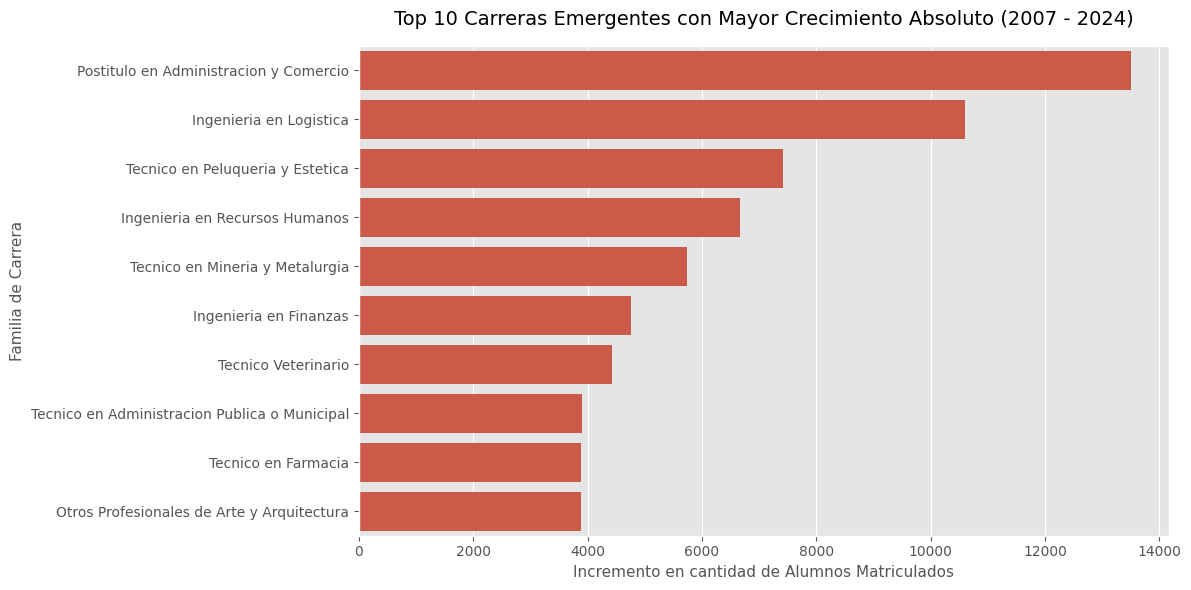

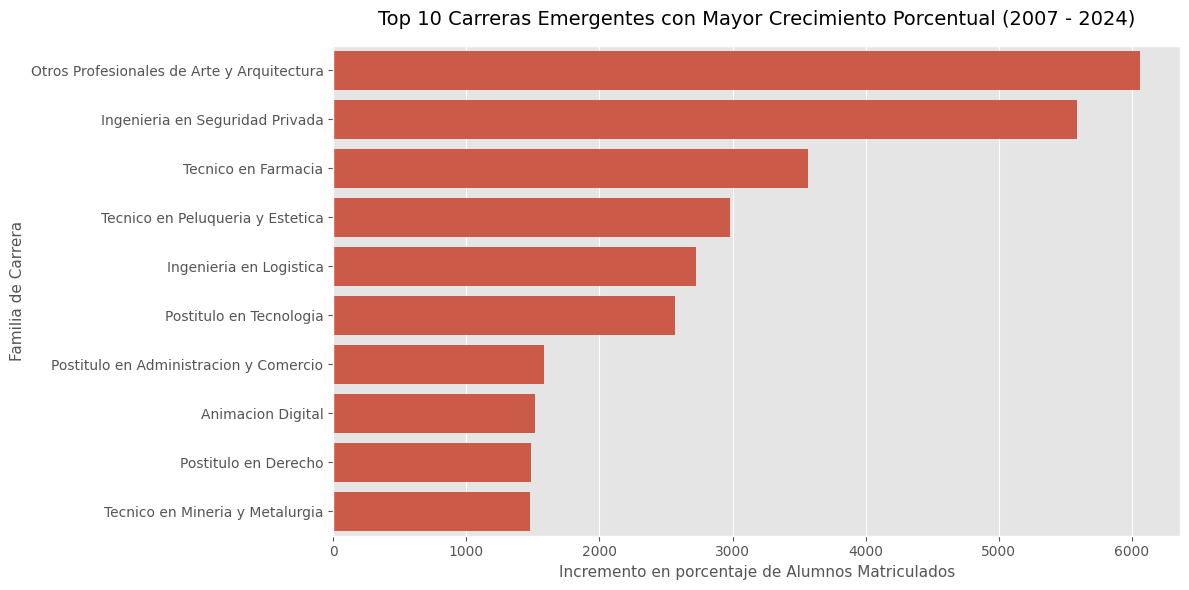

In [56]:
# Formato al DataFrame para exportar a Excel o Markdown
df_reporte = df_filtrado[['familia_carrera', '2007', '2024', 'crecimiento_absoluto', 'tasa_crecimiento_porcentual']].copy()

# Redondear matrículas a enteros y porcentaje a 1 decimal
df_reporte['2007'] = df_reporte['2007'].astype(int)
df_reporte['2024'] = df_reporte['2024'].astype(int)
df_reporte['crecimiento_absoluto'] = df_reporte['crecimiento_absoluto'].astype(int)
df_reporte['tasa_crecimiento_porcentual'] = df_reporte['tasa_crecimiento_porcentual'].round(1)

print("### TOP 10 CARRERAS CON MAYOR CRECIMIENTO ABSOLUTO ###")
print(df_reporte.head(10).to_markdown(index=False))

# Generar gráfico de barras del Top 10 Crecimiento absoluto
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_reporte.head(10),
    x='crecimiento_absoluto',
    y='familia_carrera'
)
plt.title('Top 10 Carreras Emergentes con Mayor Crecimiento Absoluto (2007 - 2024)', fontsize=14, pad=15)
plt.xlabel('Incremento en cantidad de Alumnos Matriculados', fontsize=11)
plt.ylabel('Familia de Carrera', fontsize=11)
plt.tight_layout()
plt.show()

# Genenrar grafico de barras del Top 10 Crecimiento porcentual
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_reporte.sort_values(by='tasa_crecimiento_porcentual', ascending=False).head(10),
    x='tasa_crecimiento_porcentual',
    y='familia_carrera'
)
plt.title('Top 10 Carreras Emergentes con Mayor Crecimiento Porcentual (2007 - 2024)', fontsize=14, pad=15)
plt.xlabel('Incremento en porcentaje de Alumnos Matriculados', fontsize=11)
plt.ylabel('Familia de Carrera', fontsize=11)
plt.tight_layout()
plt.show()

*OBS 5: En la grafica del Top 10 Crecimiento porcentual, es posible apreciar que es posible realizar 3 agrupaciones:*

- *Grupo 1: Crecimiento < 1.500%*
- *Grupo 2: 1.500% < Crecimiento < 4.000%*
- *Grupo 3: Crecimiento > 4.000%*

In [57]:
# Cruce de top 10 absoluto y top 10 porcentual
top_10_absoluto = df_reporte.head(10)
top_10_porcentual = df_reporte.sort_values(by='tasa_crecimiento_porcentual', ascending=False).head(10)

join_top_10 = pd.merge(
    top_10_absoluto,
    top_10_porcentual,
    on='familia_carrera',
    suffixes=('_absoluto', '_porcentual'),
    how='inner'
)
carreras_top_10 = join_top_10['familia_carrera']
carreras_top_10

,familia_carrera
0,Postitulo en Administracion y Comercio
1,Ingenieria en Logistica
2,Tecnico en Peluqueria y Estetica
3,Tecnico en Mineria y Metalurgia
4,Tecnico en Farmacia
5,Otros Profesionales de Arte y Arquitectura


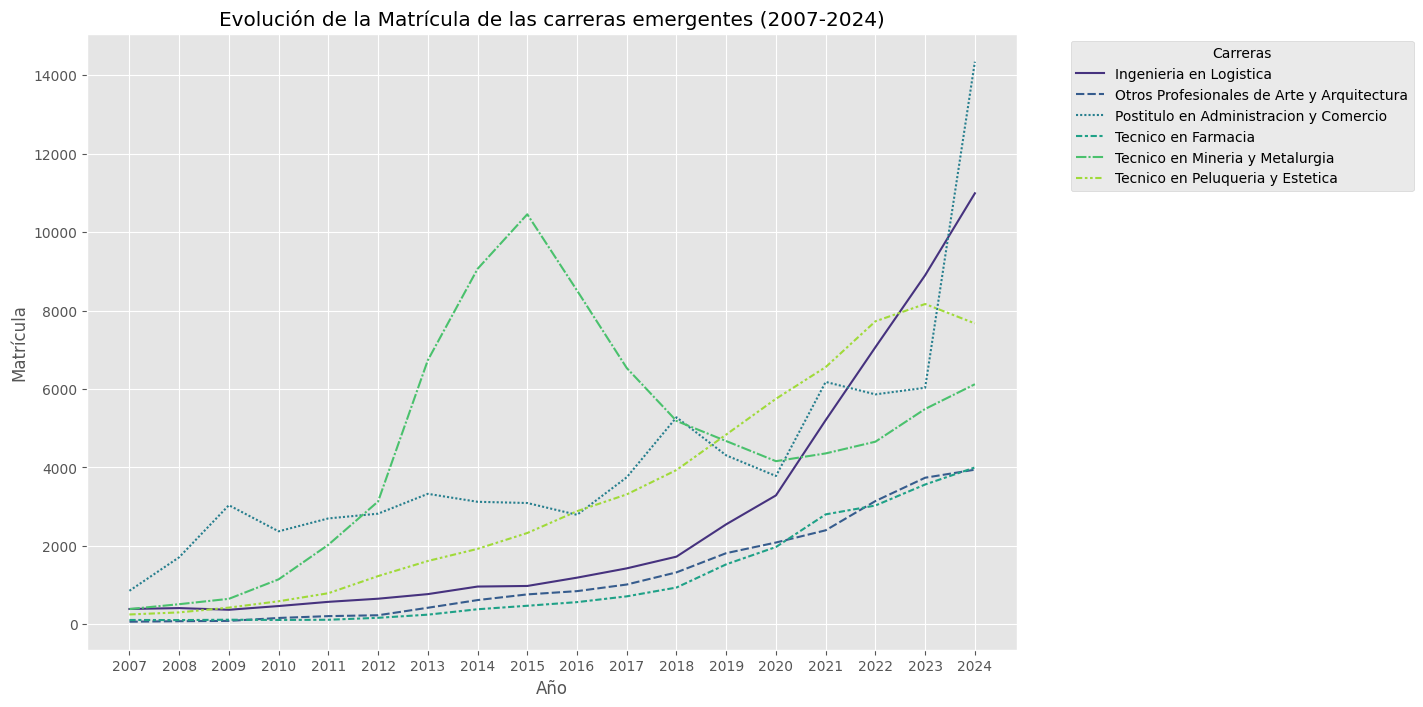

In [58]:
# Evolución Carreras Top 10
carreras_top_10_data = df_carreras.pivot_table(
    index=['familia_carrera'],
    columns='cat_periodo',
    values='total_alumnos',
    aggfunc='sum',
    fill_value=0
)

carreras_top_10_data.columns = [f'{col}' for col in carreras_top_10_data.columns]
carreras_top_10_data= carreras_top_10_data.reset_index()
carreras_top_10_data['familia_carrera'] = carreras_top_10_data['familia_carrera'].apply(preprocesar_carrera)
carreras_top_10_data= carreras_top_10_data.groupby('familia_carrera').sum().reset_index()

carreras_top_10_data = carreras_top_10_data[carreras_top_10_data['familia_carrera'].isin(carreras_top_10)]

# visualizacion de la evolucion de los top 10
plt.figure(figsize=(12, 8))
sns.lineplot(data=carreras_top_10_data.set_index("familia_carrera").T, palette='viridis')
plt.title('Evolución de la Matrícula de las carreras emergentes (2007-2024)')
plt.xlabel('Año')
plt.ylabel('Matrícula')
plt.legend(title='Carreras', bbox_to_anchor=(1.05, 1))
plt.show()

*OBS 6: En este grafico es posible apreciar diferentes fenómenos. En primer lugar, la carrera **Técnico en Minería y Metalurgia** tuvo un crecimiento explosivo hasta 2015, probablemente, este peak esta ligado a la actividad minera de la época.*

*Las carreras de **Ingeniería en logística**, **Técnico en Minería y Metalurgia** y el **Postítulo en Administración y Comercio**, son carreras alineadas al eje productivo chileno, el cual esta dominado por la mineria, los servicios, retail y banca.*

*La mayoria de las carreras analizadas en este análisis, disminuyeron sus matriculas en 2020 por la crisis del Covid-19. en cambio, las carreras de este listado (**Técnico en Peluquería y Estética**, **Otros Profesionales de Arte y Arquitectura**, **Técnico en Farmacia** e **Ingeniería en Logística**) aumentaron sus matriculas en ese año, sin embargo hay que considerar que todas ellas ya venian con una demanda creciente en sus matrículas*

*Llama la atención el salto de **Postítulo en Administración y Comercio** en 2024, el cual casi triplica la cantidad de matriculas de 2023, pasando de 6032 a 14348 matrículas (+238%).*

### IV. Análisis de Otros Profesionales de Arte y Arquitectura

#### Análisis de áreas de carreras

En el apartado anterior, se observó que la familia de carreras *"Otros Profesionales de Arte y Arquitectura"* tuvieron un crecimiento superior al 6.000%

|Carrera|Crecimiento Absoluto|Crecimiento %|
|:-:|:-:|:-:|
|Otros Profesionales de Arte y Arquitectura|3.878|6.059 %|
|Ingeniería en Seguridad Privada|3.131|5.591 %|
|Ingeniería en Energía y Recursos Renovables|2.067|488 %|

Por lo que se indagará como se compone esa "familia" de carreras para tener un detalle más completo.

**Recursos:**
- [Consulta SQL](https://github.com/FeliProjects/analisis-educacion-superior-chile/blob/main/sql/06_bo3_otros_arte_arq.sql)
- [Dataset](https://github.com/FeliProjects/analisis-educacion-superior-chile/blob/main/data/processed/bo_3_otros_arte_arq.csv)


| area_carrera_generica       |   2007 |   2008 |   2009 |   2010 |   2011 |   2012 |   2013 |   2014 |   2015 |   2016 |   2017 |   2018 |   2019 |   2020 |   2021 |   2022 |   2023 |   2024 |
|:----------------------------|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|
| Arquitectura y Construcción |      0 |      0 |      0 |      0 |      0 |      0 |      0 |      0 |      1 |      3 |      3 |      6 |      8 |      8 |      8 |     12 |     11 |     14 |
| Artes                       |     64 |     77 |     85 |    115 |    131 |    122 |    139 |    195 |    273 |    325 |    428 |    620 |    762 |    890 |   1098 |   1221 |   1382 |   1416 |
| Servicios Personales        |      0 |      0 |      0 |     45 |     76 |    107 |    281 |    421 |    487 |    516 |    582 |    697 |   1043 |   1186 |   1290 |   1909 |   2344 |   2512 |


<Axes: >

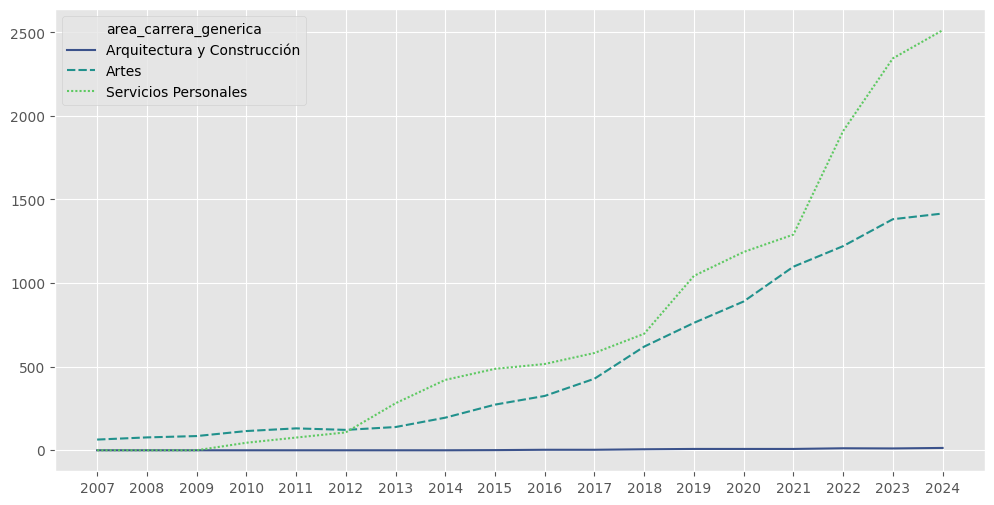

In [59]:
bo3_artearq_file_path = BASE_PATH / "bo_3_otros_arte_arq.csv"

otros_arte_arq = pd.read_csv(bo3_artearq_file_path)

otros_pivoted = otros_arte_arq.pivot_table(index='area_carrera_generica', columns='cat_periodo', values='total_estudiantes', aggfunc='sum', fill_value=0)
otros_pivoted.columns = [f'{col}' for col in otros_pivoted.columns]
otros_pivoted = otros_pivoted.reset_index()

print(otros_pivoted.to_markdown(index=False))

plt.figure(figsize=(12, 6))
sns.lineplot(data=otros_pivoted.set_index("area_carrera_generica").T, palette='viridis')

*OBS 7: Es posible observar que la agrupación "Otros Profesionales de Arte y Arquitectura" agrupa carreras de "Arquitectura y Construcción", "Artes" y "Servicios Personales", sin embargo, las carreras relacionadas a "Arquitectura" son mínimas, representando un 0.4% de las matrículas de 2024, versus el ~63% de "Servicios Personales" y ~36% de "Artes".*

*Esto plantea interrogantes sobre la idoneidad del nombre de la categoría o bien sobre la clasificación realizada por las instituciones educativas.*

#### Análisis de nombres de carreras

Para profundizar aún más en estas categorías, se analizaran los nombres específicos de cada carrera.

**Recursos:**
- [Consulta SQL](https://github.com/FeliProjects/analisis-educacion-superior-chile/blob/main/sql/07_bo3_otros_carreras.sql)
- [Dataset](https://github.com/FeliProjects/analisis-educacion-superior-chile/blob/main/data/processed/bo_3_otros_carreras.csv)

|    | nomb_carrera         |   2007 |   2008 |   2009 |   2010 |   2011 |   2012 |   2013 |   2014 |   2015 |   2016 |   2017 |   2018 |   2019 |   2020 |   2021 |   2022 |   2023 |   2024 |
|---:|:---------------------|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|
|  0 | CREACION AUDIOVISUAL |      0 |      0 |      0 |      0 |      0 |      0 |      0 |      0 |      0 |      0 |      0 |     31 |     62 |     90 |    111 |    138 |    146 |    156 |
|  1 | ESTETICA PROFESIONAL |      0 |      0 |      0 |     45 |     76 |    107 |    281 |    421 |    487 |    516 |    582 |    697 |   1043 |   1186 |   1290 |   1909 |   2344 |   2512 |
|  2 | ILUSTRACION          |     64 |     77 |     85 |    115 |    131 |    122 |    139 |    195 |    273 |    325 |    428 |    589 |    700 |    800 |    987 |   1083 |   1204 |   1211 |
|  3 | OFICIOS CREATIVOS    |      0 |  

<Axes: title={'center': 'Evolución de Otros Profesionales de Arte y Arquitectura por Año (2007-2024)'}>

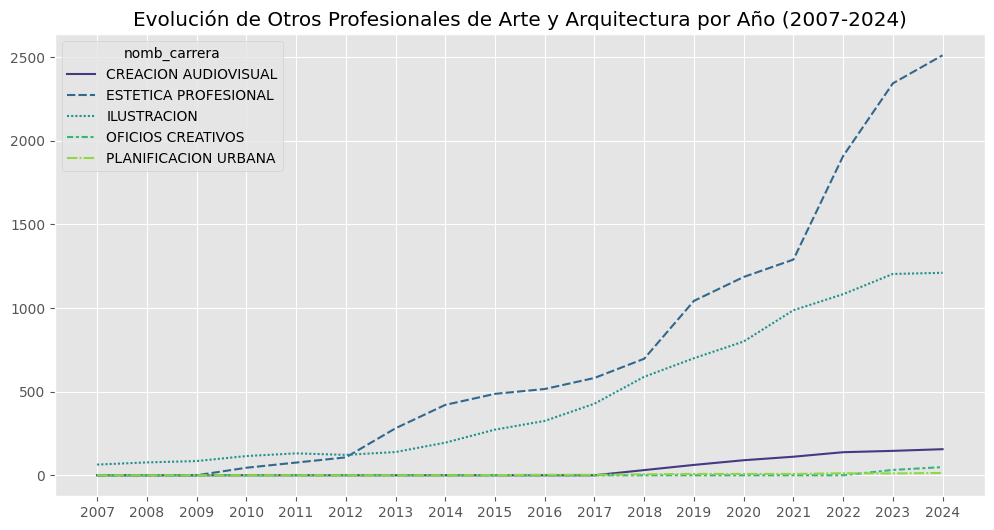

In [60]:
bo3_carreras_file_path = BASE_PATH / "bo_3_otros_carreras.csv"

otros_carreras = pd.read_csv(bo3_carreras_file_path)

otros_carreras_pivot = otros_carreras.pivot_table(index='nomb_carrera', columns='cat_periodo', values='total_estudiantes', aggfunc='sum', fill_value=0)
otros_carreras_pivot.columns = [f'{col}' for col in otros_carreras_pivot.columns]
otros_carreras_pivot = otros_carreras_pivot.reset_index()

print(otros_carreras_pivot.to_markdown())

plt.figure(figsize=(12, 6))
plt.title('Evolución de Otros Profesionales de Arte y Arquitectura por Año (2007-2024)')
sns.lineplot(data=otros_carreras_pivot.set_index("nomb_carrera").T, palette='viridis')

*OBS 8: De éste análisis se obtiene "Estética Profesional" lidera las preferencias de esta área desde 2013, seguido de "Ilustración".*

*Tambien es posible distinguir la carrera mas "jóven" es Oficios Creativos, registrando sus primeras matriculas en 2023.*

*Se aprecia que la única carrera ligada a la arquitectura es "Planificación Urbana" y tambien es la carrera con menos estudiantes, debido a esto, se podría considerar que el nombre de la categoría "Otros Profesionales de Arte y Arquitectura" podria no ser representativo de las carreras que lo componen.*

*Del mismo modo, la carrera "Estética Profesional" podria estar en otra categoría ya que la descripción dada por IP AIEP indica lo siguiente "Un Esteticista Profesional es un especialista en cosmetología y estética integral, enfocado en el cuidado y embellecimiento de la piel y el cuerpo. Brinda tratamientos personalizados en clínicas estéticas, centros de estética integral, y trabaja junto a expertos en medicina estética para mejorar el bienestar de sus clientes." por lo que podría indicar que está más ligado al área de la salud y bienestar que del arte.*

### V. Consusiones e Insights

#### 1. Educación Técnica vs. Profesional

* **Resultados:** Tal como se definió anteriormente en el apartado *III. Análisis de Carreras Emergentes*, para identificar estas carreras, se aplicó un filtro basado en percentiles, en el cual se seleccionaron aquellas carreras con una matrícula en 2007 menor o igual al percentil 50 de la distribución (≤ 877 alumnos) y una matrícula en 2024 mayor o igual al percentil 50 de la distribución (≥ 2.130 alumnos). Este criterio asegura que las carreras seleccionadas partieron desde una base baja o media y lograron consolidarse en el tiempo, superando la mediana del sistema educativo.


  El resultado fue un conjunto de 22 carreras que representan las trayectorias de crecimiento más significativas del período 2007-2024, representadas en la siguiente tabla:

  | familia_carrera  |   2007 |   2024 |   crecimiento_absoluto |   tasa_crecimiento_porcentual |
  |:----------------|-------:|-------:|------------:|------------:|
  | Postitulo en Administracion y Comercio        |    853 |  14348 |                  13495 |                        1582.1 |
  | Ingenieria en Logistica                       |    389 |  10992 |                  10603 |                        2725.7 |
  | Tecnico en Peluqueria y Estetica              |    249 |   7673 |                   7424 |                        2981.5 |
  | Ingenieria en Recursos Humanos                |    844 |   7516 |                   6672 |                         790.5 |
  | Tecnico en Mineria y Metalurgia               |    387 |   6122 |                   5735 |                        1481.9 |
  | Ingenieria en Finanzas                        |    471 |   5229 |                   4758 |                        1010.2 |
  | Tecnico Veterinario                           |    812 |   5237 |                   4425 |                         545   |
  | Tecnico en Administracion Publica o Municipal |    395 |   4293 |                   3898 |                         986.8 |
  | Tecnico en Farmacia                           |    109 |   3999 |                   3890 |                        3568.8 |
  | Otros Profesionales de Arte y Arquitectura    |     64 |   3942 |                   3878 |                        6059.4 |
  | Tecnico en Podologia                          |    601 |   4408 |                   3807 |                         633.4 |
  | Postitulo en Ciencias Sociales                |    670 |   4343 |                   3673 |                         548.2 |
  | Postitulo en Derecho                          |    239 |   3796 |                   3557 |                        1488.3 |
  | Postitulo en Tecnologia                       |    135 |   3603 |                   3468 |                        2568.9 |
  | Animacion Digital                             |    222 |   3580 |                   3358 |                        1512.6 |
  | Ingenieria en Marketing                       |    623 |   3928 |                   3305 |                         530.5 |
  | Ingenieria en Seguridad Privada               |     56 |   3187 |                   3131 |                        5591.1 |
  | Magister en Derecho                           |    850 |   3150 |                   2300 |                         270.6 |
  | Magister en Ciencias Basicas                  |    598 |   2878 |                   2280 |                         381.3 |
  | Magister en Salud                             |    837 |   3107 |                   2270 |                         271.2 |
  | Ingenieria en Energia y Recursos Renovables   |    424 |   2491 |                   2067 |                         487.5 |
  | Otros Profesionales de Educacion              |    616 |   2394 |                   1778 |                         288.6 |

* **Especialización:** Al agrupar las carreras se obtiene la siguiente tabla:
  |Tipo de Estudio|Tipo de Carrera|Cantidad|%|
  |:-:|:-:|:-:|:-:|
  |Postítulo|Postgrado|7|32%|
  |Ingeniería|Pregrado|6|27%|
  |Técnico|Pregrado|6|27%|
  |Otros Profesionales|Pregrado|3|14%|

  El análisis mostró que de las 22 carreras emergentes, 7 (32%) son Postgrados. Esto es indicio de que el mercado de los profesionales se ha ido acotando en el transcurso del tiempo, requiriendo más conocimientos y más especialización. Por otra parte, también refleja una necesidad de los profesionales por diferenciarse del resto, en un mercado cada vez más competitivo.

* **Polo Técnico:** En las carreras emergentes se presenta una inclinación hacia las carreras técnicas y aplicadas (Técnico + Ingeniería = 54%), las cuales tambien tienden a alinearse con el mercado y la matriz productiva chilena.

#### 2. Matriz Productiva Chilena

* **Reflejo Macroeconómico:** Dentro de las carreras emergentes, se aprecia un reflejo de la matriz económica y productiva chilena. De las carreras que ganaron mas relevancia, la mayoría se alinea con el sector minero (Técnico en Minería y Metalurgia), comercio (Ingeniería en Logística, Postítulo en Administración y Comercio y Técnico en Farmacia), banca y servicios (Técnico en Peluquería y Estética y Otros Profesionales de Arte y Arquitéctura).

* **Ascenso y Caida de la Minería:** Entre 2004 y 2015 se produjo un aumento fuerte de la carrera Técnico en Minería y Metalurgia, sin embargo posteriormente se produce un descenso pocas veces visto en la historia. En 2021 vuelve a retomar el ritmo alcista pero ya a una tasa mas acorde al resto de las carreras.

#### 3. Otras carreras de interés

* **Otros Análisis:** El anális presentó otras carreras emergentes que no se encasillan tanto con la matriz productiva chilena:

  |Familia Carrera|Crecimiento Absoluto|Crecimiento %|
  |:--|--:|--:|
  |Otros Profesionales de Arte y Arquitectura|3.878|6.059 %|
  |Ingeniería en Seguridad Privada|3.131|5.591 %|
  |Ingeniería en Energía y Recursos Renovables|2.067|488 %|

* **Un nicho debido a problemas de seguridad del país:** La carrera Ingeniería en Seguridad Privada tuvo un crecimiento del 5.591%, lo cual lo ubica en el segundo lugar de crecimiento, solo por debajo de *Otros Profesionales de Arte y Arquitectura* (6.059%). Este aumento coincide con el aumento de la delincuencia y las modificaciones a las normativas que traspasan algunas responsabilidades de seguridad a las empresas e instituciones privadas. Esto sugiere que la evolución de esta carrera responde a un cambio regulatorio y social, no solo a una moda educativa. Probablemente, si los problemas de seguridad no se abordan desde una perspectiva global, es posible que este nicho siga expandiendose.

* **Crecimiento mermado:** La carrera Ingeniería en Energía y Recursos Renovables, no ha tenido un crecimiento grande a pesar del potencial energetico chileno. Una hipótesis implica que esto podria atribuirse a al solapamiento con carreras afines, tales como Ingeniería Electrica y Electrónica, Ingeniería Mecánica o Ingeniería Industrial, ya que tienen curriculos con un fuerte componente energético con enfoque en energías limpias. Se requiere un análisis de mallas curriculares y de empleabilidad por sector para poder confirmar o refutar esta hipótesis.

* **Posible categorización deficiente:** La familia de carreras de "Otros Profesionales de Arte y Arquitectura" posee las siguiente matriculas en 2024:

  |Nombre Carrera|Matrículas 2024|% Matrículas|
  |:--|--:|--:|
  |Estética Profesional|2.512|63,7 %|
  |Ilustración|1.211|30,7 %|
  |Creación Audiovisual|156|4,0 %|
  |Oficios Creativos|49|1,2 %|
  |Planificación Urbana|14|0,4 %|
  |Total|3942||

  De esta tabla, es posible apreciar que solo "Planificación Urbana" se encuentra ligada a "Arquitectura" y con muy pocas matriculas, representando apenas el 0.4% del total en 2024. También, el 63.7% de las matriculas de 2024 corresponde a "Estética Profesional", la cual, de acuerdo a la descripción dada por la unica institución que imparte esta carrera, posee más afinidad con el área de la salud y bienestar como podría ser "Otros Profesionales de Salud".

#### 4. Consideraciones Futuras

Para futuros analisis seria interesante ver análisis que considere otras variables para entender el comportamiento de la educación superior desde distintas perspectivas:
- **Ciclo de formación:** Un análisis del desarrollo académico realizado por los estudiantes (Técnico > Profesional > Postítulo) para entender su comportamiento en las diferentes areas de conocimiento.
- **Movilidad Institucional:** Un análisis del desarrollo del estudiante relacionado a las diferentes instituciones. Esto permitiría entender si las casas de estudio logran captar el interes de los estudiantes que desean seguir con sus estudios. Analizar los factores de los motivos podría tener dificultades ya que no se tiene acceso a identificar al estudiante para validar alguna hipótesis.